# Bayesian Forecasting for Finance

**The whole idea in one sentence: stop forecasting a number, forecast a distribution, and let the data tell you how wide that distribution honestly has to be.** By the end of this notebook you will have fitted a small hierarchical Bayesian model of daily crypto returns with PyMC. You will have sampled it with modern MCMC, checked the sampler's homework with the proper diagnostics, and checked the *model's* homework with posterior predictive checks. The payoff is a 30-day probabilistic forecast with honest credible intervals, all from free Binance data with no API key.

Every section follows the same rhythm: the key point first, then the intuition, then a sentence or two on the maths, then the common ways it goes wrong. Where a concept is subtle we first build it on small **synthetic data** -- a clean, controlled example where we know the right answer -- and only then apply it to the real market data. Short **Key takeaway** callouts mark the lines worth remembering; **What to look for** callouts name the figures and thresholds that matter. If you only skim, read those.

**What we will cover**
1. Why Bayesian: distributions, not point estimates (priors, likelihood, posterior)
2. The data: daily crypto returns and their fat tails (and why normal models fail)
3. Partial pooling: the hierarchical model, built on a synthetic shrinkage demo first
4. Sampling with NUTS, and reading the diagnostics rather than your hopes
5. Posterior predictive checks: does the model look like the data?
6. The payoff: a probabilistic 30-day forecast (a fan chart)
7. Calibration, proper scoring rules, and point-in-time discipline
8. Caveats and where to go next

A **Further reading and resources** section at the end collects the canonical papers, books and documentation behind every technique used here.

> **Data:** Binance public daily klines (free, no key, history back to 2017).
> **Nothing here is investment advice.** It is an educational walkthrough of a method, with its weaknesses stated as plainly as its strengths.

In [1]:
# --- Setup -------------------------------------------------------------------
import sys, os, sysconfig, warnings
from pathlib import Path

# PyMC compiles its log-probability to fast C, which needs the Python dev headers
# (Python.h). In a virtualenv, sysconfig points at the venv's own include dir, which does
# not contain the headers; the real ones live with the base interpreter. We locate a
# Python.h on the system and hand its directory to PyTensor's compiler. If none can be
# found we fall back to the pure-Python backend (much slower, but it always runs).
def _find_python_headers() -> str | None:
    candidates = [
        sysconfig.get_path("include"),                          # venv (usually no headers)
        sysconfig.get_path("platinclude"),
        sysconfig.get_config_var("INCLUDEPY"),                  # base interpreter include
        f"/usr/include/python{sys.version_info.major}.{sys.version_info.minor}",
    ]
    for d in candidates:
        if d and Path(d, "Python.h").exists():
            return d
    return None

_inc = _find_python_headers()
if _inc:
    os.environ.setdefault("PYTENSOR_FLAGS", f"gcc__cxxflags=-I{_inc}")
    print(f"Using fast C backend with Python headers at {_inc}")
else:
    os.environ.setdefault("PYTENSOR_FLAGS", "cxx=,mode=FAST_COMPILE")
    print("Python.h not found: using PyTensor's pure-Python backend (slower but portable).")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats as st
import pymc as pm
import arviz as az

sys.path.append(str(Path.cwd().parent))          # so we can import src/
from src.data import get_closes
from src.style import use_house_style, PALETTE, titled

warnings.filterwarnings("ignore")
use_house_style()
RNG = np.random.default_rng(42)
ASSETS = Path.cwd().parent / "assets"; ASSETS.mkdir(exist_ok=True)
def save(fig, name): fig.savefig(ASSETS / name); return fig

print(f"PyMC {pm.__version__}, ArviZ {az.__version__}")

Using fast C backend with Python headers at /usr/include/python3.12


PyMC 6.0.1, ArviZ 1.2.0


## 1. Why Bayesian: distributions, not point estimates

**A point forecast hides the one thing a risk-taker most needs to know: how sure are we?** "Volatility next month will be 3.1%" means something completely different if the plausible range is 2.9% to 3.3% than if it is 1% to 6%. Yet the point forecast reads identically in both cases. Bayesian inference is the machinery for keeping that range attached to every number you report.

The intuition is a detective updating a theory as evidence arrives. Before the evidence you hold some spread of suspicion across the suspects. That is the **prior**, written `p(θ)`: your beliefs about the unknown quantity θ before seeing this data. Each piece of evidence is more consistent with some suspects than others. That weighing is the **likelihood**, `p(data | θ)`: the model's statement of how probable the observed data would be for each candidate value of θ. What you are entitled to believe afterwards is the **posterior**, `p(θ | data)`. Bayes' rule is the bookkeeping that combines them:

$$ p(\theta \mid \text{data}) \;\propto\; p(\text{data} \mid \theta)\; p(\theta) $$

The $\propto$ symbol means "is proportional to". The right-hand side gives the correct *relative* probability at each value of θ, but does not yet integrate to one. The normalising constant $p(\text{data}) = \int p(\text{data} \mid \theta)\,p(\theta)\,d\theta$ rescales it into a proper probability distribution. In practice we almost never compute that constant. Instead we draw samples whose frequency is automatically proportional to the right-hand side.

The crucial point is that the posterior is a full *distribution*, not a point. Every downstream quantity inherits a distribution too -- a forecast, a value-at-risk number, the probability of breaching a level -- with its uncertainty attached rather than thrown away. The standard summary is a **credible interval**: a range that contains the unknown with a stated posterior probability. That is the plain-English statement most people wrongly believe a frequentist confidence interval makes.

Two pitfalls before we start.

First, the prior is not a licence to smuggle in opinions. It should encode mild, defensible knowledge ("daily crypto volatility is a few percent, not a few hundred percent"), and you should check that conclusions survive reasonable alternatives.

Second, with very little data the prior dominates; with a lot of data it barely matters. Knowing which regime you are in is part of reading any Bayesian result honestly.

### Synthetic warm-up: watch a posterior learn

Here is the entire mechanism on a controlled example where we know the truth. **Synthetic, illustrative data:** a biased coin with a true heads-probability of 0.65, which in real life we would not know. We start from a mild prior centred on "roughly fair" and update it after 5, 20, 100 and 500 tosses. This uses the Beta-Binomial conjugate pair, the one textbook case where the posterior has a closed form, which is exactly why it makes a clean demo.

The posterior starts wide -- honest ignorance -- then narrows roughly as 1/√n as evidence accumulates. No single update is dramatic. The discipline is that the width always reflects how much evidence has actually arrived.

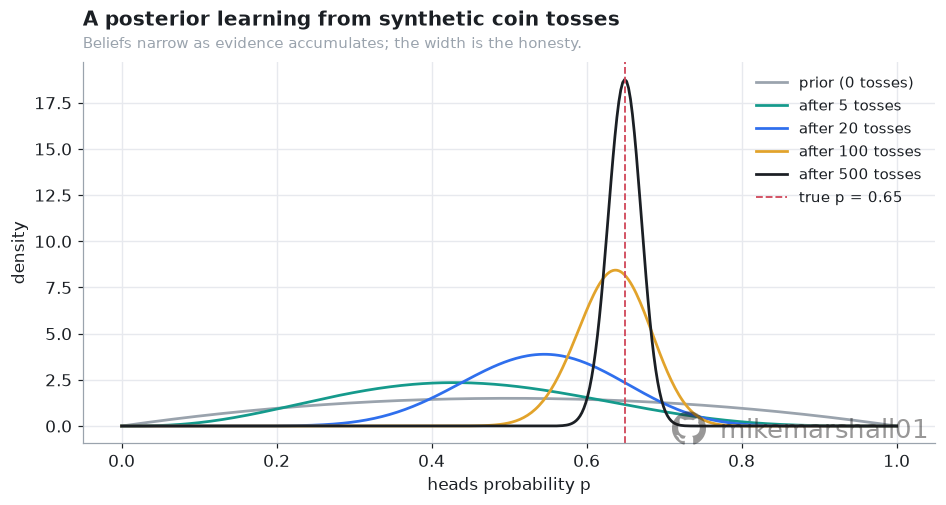

after   5 tosses: posterior mean 0.444, 94% credible [0.166, 0.744]  (width 0.579)
after  20 tosses: posterior mean 0.542, 94% credible [0.353, 0.725]  (width 0.372)
after 100 tosses: posterior mean 0.635, 94% credible [0.544, 0.721]  (width 0.176)
after 500 tosses: posterior mean 0.649, 94% credible [0.608, 0.688]  (width 0.080)


In [2]:
# --- SYNTHETIC: Beta-Binomial updating on a coin with known bias -------------
TRUE_P = 0.65
tosses = (RNG.random(500) < TRUE_P).astype(int)            # synthetic data, truth known
a0, b0 = 2.0, 2.0                                          # mild prior centred on 0.5

grid = np.linspace(0, 1, 400)
checkpoints = [0, 5, 20, 100, 500]
colours = [PALETTE["grey"], PALETTE["teal"], PALETTE["blue"], PALETTE["amber"], PALETTE["ink"]]

fig, ax = plt.subplots()
for n, c in zip(checkpoints, colours):
    h = tosses[:n].sum()
    ax.plot(grid, st.beta.pdf(grid, a0 + h, b0 + (n - h)), color=c, lw=1.8,
            label=f"after {n} tosses" if n else "prior (0 tosses)")
ax.axvline(TRUE_P, color=PALETTE["red"], ls="--", lw=1.2, label=f"true p = {TRUE_P}")
ax.set_xlabel("heads probability p"); ax.set_ylabel("density"); ax.legend()
titled(ax, "A posterior learning from synthetic coin tosses",
       "Beliefs narrow as evidence accumulates; the width is the honesty.")
save(fig, "01_beta_updating.png"); plt.show()

for n in checkpoints[1:]:
    h = tosses[:n].sum()
    lo, hi = st.beta.ppf([0.03, 0.97], a0 + h, b0 + (n - h))
    print(f"after {n:>3} tosses: posterior mean {((a0+h)/(a0+b0+n)):.3f}, "
          f"94% credible [{lo:.3f}, {hi:.3f}]  (width {hi-lo:.3f})")

The intervals shrink steadily. By 500 tosses the posterior has closed in around the true 0.65. The early, wide intervals were *also* correct in the only sense that matters: they contained the truth while honestly admitting how little was known. That is the behaviour we want from a financial forecast, where the truth is never revealed and the width of the interval is the product.

> **What to look for.** Posterior width shrinking roughly as $1/\sqrt{n}$; a prior that visibly matters at n = 5 and is irrelevant by n = 500. If a posterior barely narrows as data arrives, the data carry little information about that parameter. If it is implausibly narrow early, the prior is doing the talking.

> **Key takeaway.** Bayesian inference is belief bookkeeping: prior times likelihood, renormalised. The output is a distribution, and the width of that distribution is not a nuisance, it is the deliverable.

## 2. The data: daily crypto returns and their fat tails

**The single empirical fact that shapes the whole model: extreme days are far more common than a normal distribution allows.** We work with daily **log returns** (the day-over-day change in log price), because they add across time and are roughly symmetric. We scale them to percent so the priors are easy to reason about.

In [3]:
# --- Load free Binance daily closes for three liquid majors ------------------
SYMBOLS = ["BTCUSDT", "ETHUSDT", "SOLUSDT"]
px = get_closes(SYMBOLS, interval="1d", start="2021-01-01")

rets = np.log(px).diff().dropna() * 100.0        # daily log returns, in percent
ASSET_NAMES = list(rets.columns)
N_ASSETS = len(ASSET_NAMES)

print(f"{rets.shape[0]} daily returns, {N_ASSETS} assets, "
      f"{rets.index.min().date()} -> {rets.index.max().date()}")
rets.tail(3).round(2)

1988 daily returns, 3 assets, 2021-01-02 -> 2026-06-12


,BTC,ETH,SOL
date,,,
2026-06-10 00:00:00+00:00,-0.36,-1.10,-2.76
2026-06-11 00:00:00+00:00,3.38,3.15,5.75
2026-06-12 00:00:00+00:00,-0.13,-0.39,-0.16


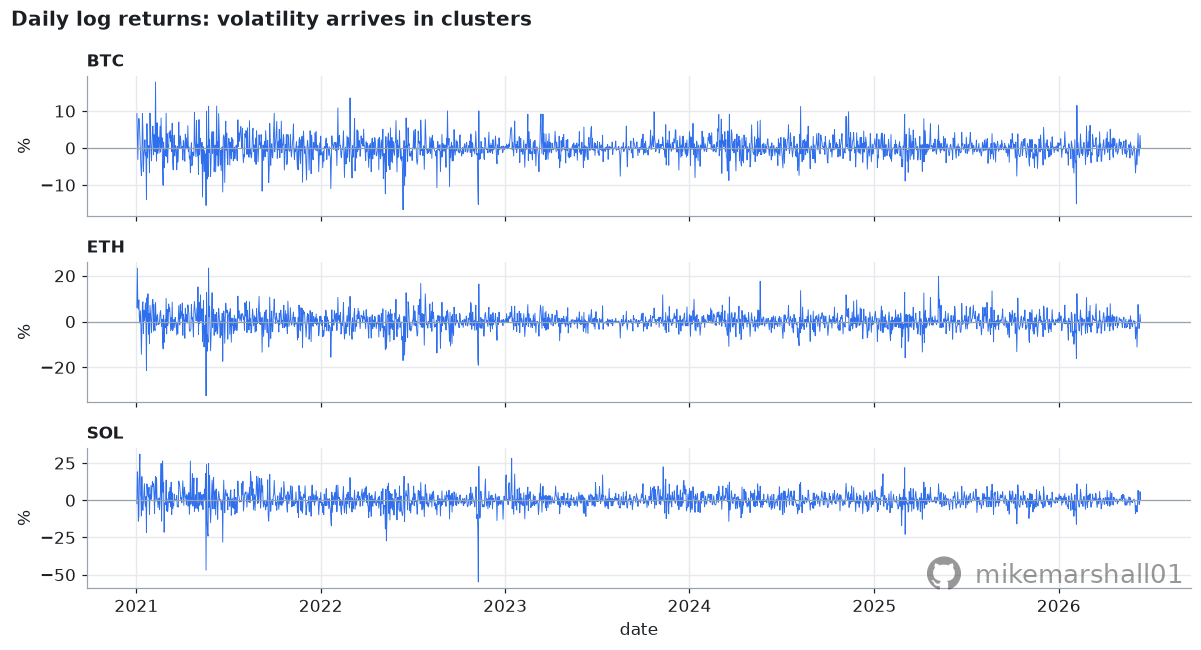

In [4]:
# Returns through time: the texture matters as much as the histogram.
fig, axes = plt.subplots(N_ASSETS, 1, figsize=(11, 6), sharex=True)
for ax, name in zip(axes, ASSET_NAMES):
    ax.plot(rets.index, rets[name], lw=0.6, color=PALETTE["blue"])
    ax.axhline(0, color=PALETTE["grey"], lw=0.8)
    ax.set_title(name, loc="left", fontsize=11)
    ax.set_ylabel("%")
axes[-1].set_xlabel("date")
fig.suptitle("Daily log returns: volatility arrives in clusters", x=0.01, ha="left",
             fontweight="bold")
fig.tight_layout()
save(fig, "01_returns_ts.png"); plt.show()

Two textures jump out. First, calm and stormy periods alternate in blocks (**volatility clustering**: a violent day is more likely to be followed by another violent day). Second, occasional single days dwarf everything around them.

Any model that assumes one constant volatility and thin tails is mis-specified for this data. Crypto exaggerates both features relative to equities, so the modelling choices below matter more here, not less. Our model will fix the tails properly and *acknowledge* the clustering as a known limitation (section 8).

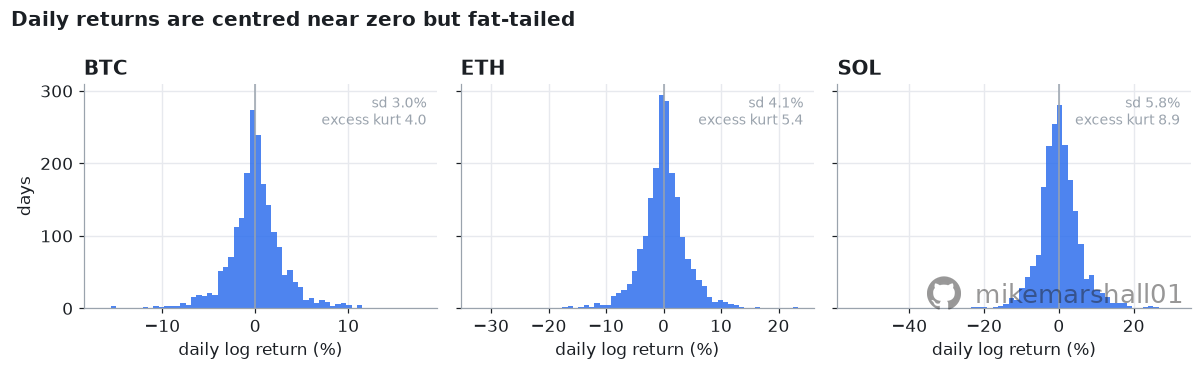

Excess kurtosis (0 = normal tails; bigger = fatter):
BTC    4.0
ETH    5.4
SOL    8.9


In [5]:
# Histograms per asset. Multi-panel rule: one short title per panel, shared context in
# the suptitle and axis labels, supporting figures annotated inside the axes.
fig, axes = plt.subplots(1, N_ASSETS, figsize=(11, 3.4), sharey=True)
for ax, name in zip(axes, ASSET_NAMES):
    ax.hist(rets[name], bins=60, color=PALETTE["blue"], alpha=0.85)
    ax.axvline(0, color=PALETTE["grey"], lw=1)
    ax.set_title(name, loc="left")
    ax.annotate(f"sd {rets[name].std():.1f}%\nexcess kurt {rets[name].kurt():.1f}",
                xy=(0.97, 0.95), xycoords="axes fraction", ha="right", va="top",
                fontsize=9, color=PALETTE["grey"])
    ax.set_xlabel("daily log return (%)")
axes[0].set_ylabel("days")
fig.suptitle("Daily returns are centred near zero but fat-tailed", x=0.01, ha="left",
             fontweight="bold")
fig.tight_layout()
save(fig, "01_returns_hist.png"); plt.show()

print("Excess kurtosis (0 = normal tails; bigger = fatter):")
print(rets.kurt().round(1).to_string())

Every asset shows positive excess kurtosis, in places dramatically so. **Kurtosis** measures tail weight (how much probability sits far from the centre). The normal distribution is the zero benchmark; values well above zero mean the extremes carry far more probability than a bell curve admits. Positive excess kurtosis tells you that risk lives in the tails rather than the everyday wiggle.

For crypto, excess kurtosis well above the normal baseline is the rule at the daily frequency. During crisis windows and for smaller tokens it regularly reaches double digits. That is why tail-aware likelihoods are the default in serious crypto work rather than a refinement.

### Proving volatility clustering: ACF of squared returns

The time-series chart above *shows* clustering, but visual impressions can deceive. The standard statistical proof is the **autocorrelation function (ACF) of squared returns** (equivalently, of absolute returns). The intuition: if large moves were independent, yesterday's large move would not predict today's. We plot the correlation between $r_t^2$ and $r_{t-k}^2$ at increasing lags $k$, which shows whether "violent yesterday" genuinely predicts "violent today". The horizontal dashed lines mark the 95% confidence threshold under the null of no autocorrelation ($\pm 1.96 / \sqrt{n}$); bars that exceed it are statistically significant.

The bars to watch are the short-lag ones -- days 1-10 and often longer -- which stay above the dashed 95% threshold. That slow decay is the smoking-gun signature of volatility clustering. Returns themselves show almost no autocorrelation (markets are mostly efficient at the daily frequency), but their *squares* do, because risk begets risk.

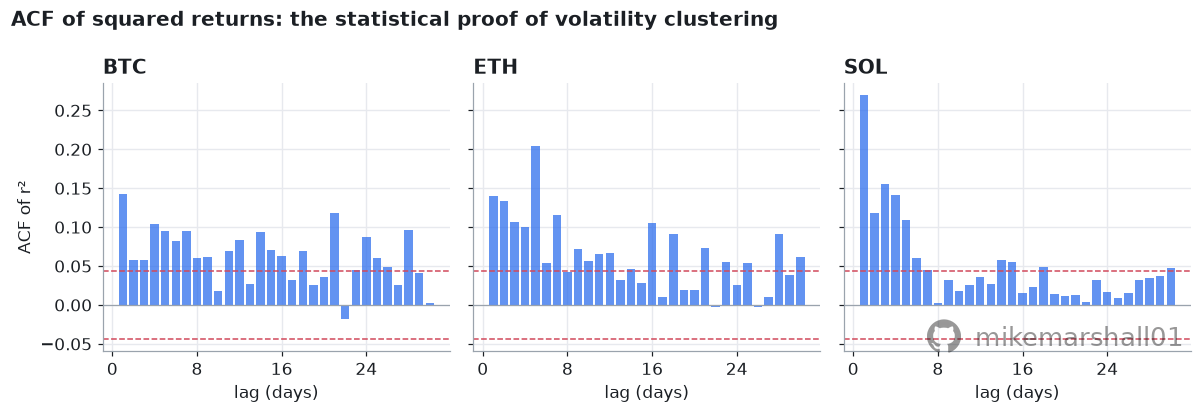

BTC: lag-1 ACF(r²) = 0.142  (significant at 95%, threshold 0.044)
ETH: lag-1 ACF(r²) = 0.140  (significant at 95%, threshold 0.044)
SOL: lag-1 ACF(r²) = 0.270  (significant at 95%, threshold 0.044)


In [6]:
# --- ACF of squared returns: prove the clustering, do not just assert it ------
from matplotlib.ticker import MaxNLocator

N_LAGS = 30
sig_threshold = 1.96 / np.sqrt(len(rets))

fig, axes = plt.subplots(1, N_ASSETS, figsize=(11, 3.8), sharey=True)
for ax, name in zip(axes, ASSET_NAMES):
    r2 = rets[name].to_numpy() ** 2
    r2_c = r2 - r2.mean()
    acf_vals = np.array([
        np.corrcoef(r2_c[:-k], r2_c[k:])[0, 1] if k > 0 else 1.0
        for k in range(N_LAGS + 1)
    ])[1:]                                          # drop lag-0 (always 1)
    lags = np.arange(1, N_LAGS + 1)
    ax.bar(lags, acf_vals, color=PALETTE["blue"], alpha=0.75, width=0.8)
    ax.axhline(sig_threshold,  color=PALETTE["red"], ls="--", lw=1, label="±95% CI")
    ax.axhline(-sig_threshold, color=PALETTE["red"], ls="--", lw=1)
    ax.axhline(0, color=PALETTE["grey"], lw=0.8)
    ax.set_title(name, loc="left")
    ax.set_xlabel("lag (days)")
    ax.xaxis.set_major_locator(MaxNLocator(integer=True, nbins=5))
axes[0].set_ylabel("ACF of r²")
fig.suptitle("ACF of squared returns: the statistical proof of volatility clustering",
             x=0.01, ha="left", fontweight="bold")
fig.tight_layout()
save(fig, "01_acf_r2.png"); plt.show()

# Print the first significant-lag autocorrelation for each asset
for name in ASSET_NAMES:
    r2 = rets[name].to_numpy() ** 2
    r2_c = r2 - r2.mean()
    acf1 = np.corrcoef(r2_c[:-1], r2_c[1:])[0, 1]
    print(f"{name}: lag-1 ACF(r²) = {acf1:.3f}  "
          f"({'significant' if abs(acf1) > sig_threshold else 'not significant'} "
          f"at 95%, threshold {sig_threshold:.3f})")

Lag-1 ACF of squared returns is positive and well above the 95% significance threshold for all three assets. The effect persists for many lags, which is the hallmark of long-memory volatility. That persistence is precisely why a constant-σ model (ours) will always mis-time its risk estimates: it is right on average but wrong in the regime that matters most.

The implication is plain. The PPC in section 5 will show the model matching tail *frequencies* but not tail *timing*. That is a known, structural limitation, and stating it here makes the PPC finding honest rather than surprising.

> **What to look for.** ACF(r²) significantly positive at lag 1 and decaying slowly over 10-30+ lags signals genuine volatility clustering that a constant-σ model cannot capture. ACF of raw returns (not squared) near zero at all lags is the sign that the market is roughly efficient at daily frequency and directional forecasting is hard.

### Synthetic interlude: what "fat tails" actually buys you

Imagine a trading day when the market moves five standard deviations. Under a normal distribution that is essentially a never-event, something that should not happen in the lifetime of the market. Under a fat-tailed distribution it is something you plan to live through. That difference is what the tail parameter ν buys you.

The fix is to swap the normal likelihood for a **Student-t** distribution. It has one extra parameter, the **degrees of freedom** ν (nu): small ν gives heavy tails, and as ν grows the distribution collapses back to the normal. The comparison below is purely **synthetic and illustrative**: two distributions with the *same mean and the same variance*, one normal and one Student-t with ν = 4, so any difference you see is tail behaviour and nothing else.

On a linear scale the two curves look almost identical -- that is how the normal assumption sneaks past visual inspection. On a log scale the normal plunges while the t tail stays orders of magnitude higher. The log scale is where risk lives.

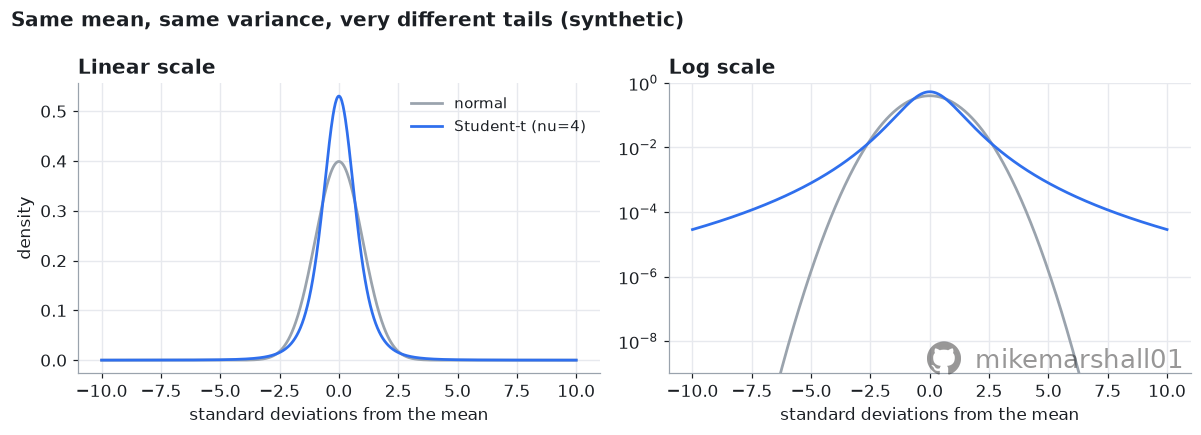

Probability of a day beyond k standard deviations (two-sided):
  |move| > 3 sd:  normal 2.70e-03 (~1 day in 1 years)   t(4) 1.32e-02 (~1 day in 0.2 years)
  |move| > 4 sd:  normal 6.33e-05 (~1 day in 43 years)   t(4) 4.81e-03 (~1 day in 0.6 years)
  |move| > 5 sd:  normal 5.73e-07 (~1 day in 4,779 years)   t(4) 2.11e-03 (~1 day in 1.3 years)
  |move| > 6 sd:  normal 1.97e-09 (~1 day in 1,388,486 years)   t(4) 1.06e-03 (~1 day in 2.6 years)


In [7]:
# --- SYNTHETIC: normal vs Student-t with identical mean and variance ---------
NU_DEMO = 4.0
t_scale = np.sqrt((NU_DEMO - 2) / NU_DEMO)       # rescale so the t has unit variance
x = np.linspace(-10, 10, 801)
pdf_n = st.norm.pdf(x)
pdf_t = st.t.pdf(x, df=NU_DEMO, scale=t_scale)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))
for ax in (ax1, ax2):
    ax.plot(x, pdf_n, color=PALETTE["grey"], lw=1.8, label="normal")
    ax.plot(x, pdf_t, color=PALETTE["blue"], lw=1.8, label=f"Student-t (nu={NU_DEMO:.0f})")
    ax.set_xlabel("standard deviations from the mean")
ax1.set_title("Linear scale", loc="left"); ax1.set_ylabel("density"); ax1.legend()
ax2.set_yscale("log"); ax2.set_ylim(1e-9, 1)
ax2.set_title("Log scale", loc="left")
fig.suptitle("Same mean, same variance, very different tails (synthetic)",
             x=0.01, ha="left", fontweight="bold")
fig.tight_layout()
save(fig, "01_tails_synthetic.png"); plt.show()

print("Probability of a day beyond k standard deviations (two-sided):")
for k in [3, 4, 5, 6]:
    p_n = 2 * st.norm.sf(k)
    p_t = 2 * st.t.sf(k / t_scale, df=NU_DEMO)
    yrs_n = 1 / (p_n * 365) if p_n > 0 else np.inf
    yrs_t = 1 / (p_t * 365)
    print(f"  |move| > {k} sd:  normal {p_n:.2e} (~1 day in {yrs_n:,.0f} years)   "
          f"t(4) {p_t:.2e} (~1 day in {yrs_t:.1f} years)")

Under the normal, a 5-sigma day is essentially a never-event; under a variance-matched t with ν = 4 it is something you should plan to live through. The general lesson: a likelihood that cannot generate the extremes will not just mis-price them. It will distort the *everyday* fit too, inflating its volatility estimate in a doomed attempt to stretch the bell over the outliers.

For markets: daily crypto returns sit firmly in the fat-tailed regime, so we let the data choose ν rather than assuming normality and hoping.

> **What to look for.** Excess kurtosis clearly above 0 in the data. A fitted ν below about 10 signals materially fat tails; ν above about 30 says the data are close to normal and the extra parameter is doing little. The fitted ν for our panel is printed in section 4.

> **Key takeaway.** Crypto returns are fat-tailed and clustered. We model the tails with a Student-t whose tail weight is learned from the data; the clustering is a known, stated limitation of this small model.

## 3. Partial pooling: the hierarchical model

**When you have several related series, the best estimate for each one borrows strength from the others, and a hierarchical model works out how much to borrow.** We have three assets. Fitting each in isolation (*no pooling*) wastes the family resemblance between them. Forcing one shared volatility (*complete pooling*) denies real differences. **Partial pooling** is the principled middle: each asset gets its own volatility, but those volatilities are drawn from a shared family distribution whose centre and spread are *also* learned. Noisy, data-poor estimates get pulled towards the family average. It is the same logic as forming a view of a new colleague that leans on your experience of colleagues in general, then updates as you spend more time with them. The pull is called **shrinkage**.

### Synthetic interlude: shrinkage beats raw estimates

**Synthetic, illustrative data:** eight "assets" whose true mean levels we draw ourselves (so we can mark the answers), observed with noise that is large where history is short. We compare the raw per-asset estimates with shrunk estimates that pull each one towards the group average in proportion to its noisiness. The shrinkage weight is the textbook signal-to-noise ratio $\tau^2 / (\tau^2 + s_k^2)$, where τ is the spread of true values across the family and $s_k$ is asset k's own noise. This is the James-Stein / empirical-Bayes effect; Efron and Morris's famous baseball example is in the further reading.

The arrows are short where history is long (asset 1, n=400) and long where it is short (asset 8, n=10). Shrunk estimates land closer to the truth on average, trading a small bias for a large variance reduction.

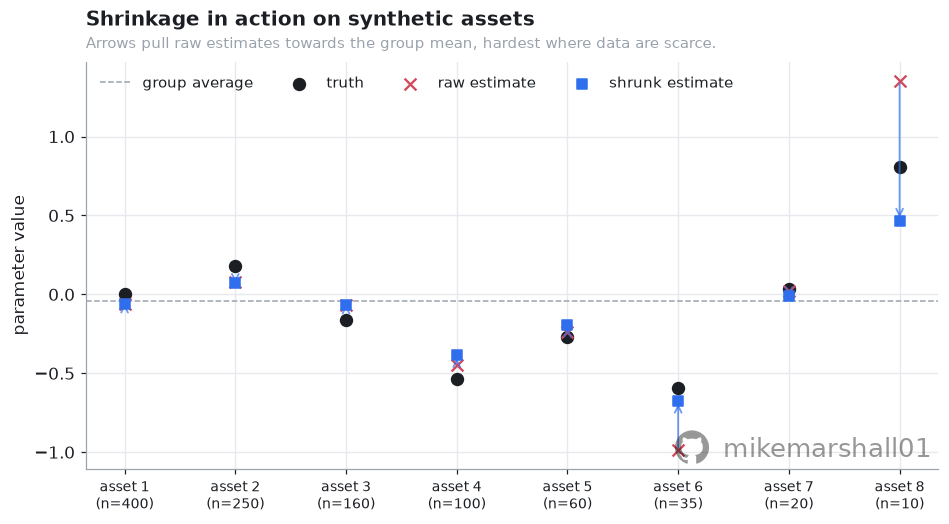

Mean absolute error vs truth:  raw 0.167   shrunk 0.119   (29% better)


In [8]:
# --- SYNTHETIC: shrinkage on 8 fake assets with known true values ------------
rng_demo = np.random.default_rng(7)
K = 8
TAU = 0.6                                          # true spread of the family
true_vals = rng_demo.normal(0.0, TAU, K)
n_days = np.array([400, 250, 160, 100, 60, 35, 20, 10])   # history length per asset
noise_sd = 2.5 / np.sqrt(n_days)                   # short history => noisy estimate
raw = true_vals + rng_demo.normal(0.0, noise_sd)

w = TAU**2 / (TAU**2 + noise_sd**2)                # signal-to-noise shrinkage weight
shrunk = w * raw + (1 - w) * raw.mean()

fig, ax = plt.subplots(figsize=(10, 4.8))
xs = np.arange(K)
ax.axhline(raw.mean(), color=PALETTE["grey"], ls="--", lw=1, label="group average")
ax.scatter(xs, true_vals, marker="o", s=60, color=PALETTE["ink"], zorder=3, label="truth")
ax.scatter(xs, raw, marker="x", s=60, color=PALETTE["red"], zorder=3, label="raw estimate")
ax.scatter(xs, shrunk, marker="s", s=40, color=PALETTE["blue"], zorder=3, label="shrunk estimate")
for i in xs:
    ax.annotate("", xy=(i, shrunk[i]), xytext=(i, raw[i]),
                arrowprops=dict(arrowstyle="->", color=PALETTE["blue"], lw=1.2, alpha=0.7))
ax.set_xticks(xs); ax.set_xticklabels([f"asset {i+1}\n(n={n})" for i, n in zip(xs, n_days)],
                                      fontsize=9)
ax.set_ylabel("parameter value"); ax.legend(ncol=4)
titled(ax, "Shrinkage in action on synthetic assets",
       "Arrows pull raw estimates towards the group mean, hardest where data are scarce.")
save(fig, "01_pooling_synthetic.png"); plt.show()

mae_raw = np.abs(raw - true_vals).mean()
mae_shrunk = np.abs(shrunk - true_vals).mean()
print(f"Mean absolute error vs truth:  raw {mae_raw:.3f}   shrunk {mae_shrunk:.3f}   "
      f"({(1 - mae_shrunk/mae_raw)*100:.0f}% better)")

The shrunk estimates beat the raw ones on average, and the gain comes almost entirely from the short-history assets, exactly where raw estimates are least trustworthy. The general rule: whenever you estimate many related quantities, the collection of individually "best" estimates is collectively beatable. In markets, new listings, thin alt-coins and short backtests are the data-poor cases where an unpooled estimate is most dangerous and pooling helps most.

### The model

For asset *a* on day *t* we model the return as Student-t with per-asset mean and volatility and a shared tail parameter:

$$ r_{a,t} \sim \text{StudentT}(\nu,\; \mu_a,\; \sigma_a) $$

- $r_{a,t}$: the daily log return of asset $a$ on day $t$.
- $\nu$ (nu, "new"): the degrees-of-freedom parameter shared across all assets; small $\nu$ gives heavy tails, large $\nu$ collapses to a normal.
- $\mu_a$: asset $a$'s average daily return (the drift, typically very small at daily frequency).
- $\sigma_a > 0$: asset $a$'s scale parameter, approximately the typical day-to-day move in percent.

The log-volatilities get a partially pooled prior (log because volatilities are positive and vary multiplicatively):

$$ \log \sigma_a \sim \mathcal{N}(\mu_\sigma,\; \tau_\sigma), \qquad
   \mu_\sigma,\,\tau_\sigma \text{ shared across assets.} $$

`mu_sigma` is the family's typical log-volatility; `tau_sigma` is how much assets genuinely differ. Those two **hyper-parameters** (parameters that govern other parameters) are what the pooling is built on. The priors are mild and stated in plain units: typical daily volatility around 3% with generous uncertainty, near-zero daily drift, and a ν prior that allows anything from very heavy tails to effectively normal.

One technical choice pays for itself: the **non-centred parameterisation**. Instead of sampling `log_sigma` directly, we sample a standard-normal `z` and build `log_sigma = mu_sigma + z * tau_sigma`. This is mathematically identical, but it removes the funnel-shaped geometry that hierarchical posteriors are notorious for. (When `tau_sigma` is small, the per-asset parameters are squeezed into a narrow neck that samplers struggle to enter.) If you ever see divergences from a hierarchical model, this is the first fix to reach for.

> **Key takeaway.** Partial pooling lets each asset speak for itself exactly in proportion to how much data it brings, and the model learns the exchange rate. The non-centred form is the standard trick that makes such models sample cleanly.

In [9]:
# --- Build the hierarchical model in PyMC ------------------------------------
# Index each return by its asset so one long vector of returns can be modelled with
# per-asset parameters via fancy indexing.
asset_idx = np.repeat(np.arange(N_ASSETS), rets.shape[0])
r_long = rets.to_numpy().T.reshape(-1)            # (asset0 days..., asset1 days...)

coords = {"asset": ASSET_NAMES}
with pm.Model(coords=coords) as model:
    # Hyper-priors: the shared family the per-asset vols are drawn from
    mu_sigma  = pm.Normal("mu_sigma", mu=np.log(3.0), sigma=0.5)   # ~3%/day typical
    tau_sigma = pm.HalfNormal("tau_sigma", sigma=0.5)              # spread across assets

    # Per-asset volatility (partially pooled, non-centred parameterisation)
    z_sigma   = pm.Normal("z_sigma", mu=0.0, sigma=1.0, dims="asset")
    log_sigma = pm.Deterministic("log_sigma", mu_sigma + z_sigma * tau_sigma, dims="asset")
    sigma     = pm.Deterministic("sigma", pm.math.exp(log_sigma), dims="asset")

    # Per-asset mean daily return (tiny; weakly informative prior)
    mu_asset  = pm.Normal("mu_asset", mu=0.0, sigma=0.5, dims="asset")

    # Fat tails, shared across assets; the data choose how heavy
    nu        = pm.Gamma("nu", alpha=2.0, beta=0.1)                # mean 20, allows heavy

    # Likelihood: Student-t innovations
    pm.StudentT("returns", nu=nu,
                mu=mu_asset[asset_idx], sigma=sigma[asset_idx],
                observed=r_long)

print("Model built. Free parameters:", [v.name for v in model.free_RVs])

Model built. Free parameters: ['mu_sigma', 'tau_sigma', 'z_sigma', 'mu_asset', 'nu']


### Visualising the Gamma(2, 0.1) prior on ν

The code comment says "mean 20, allows heavy", but that is easy to misread without a picture. The **Gamma distribution** with shape α = 2 and rate β = 0.1 has mean α/β = 20 and standard deviation $\sqrt{\alpha}/\beta = 14.14$ -- a very wide prior (coefficient of variation ≈ 71%). The plot below shows the density, annotates the prior mean, and shades the region ν < 10, the zone of *materially* fat tails. (Recall from the tail-probability table: ν = 4 is a 5-sigma-in-1-year event, and ν = 10 is still meaningfully heavier than normal.) The prior assigns substantial probability to both regimes, letting the data decide.

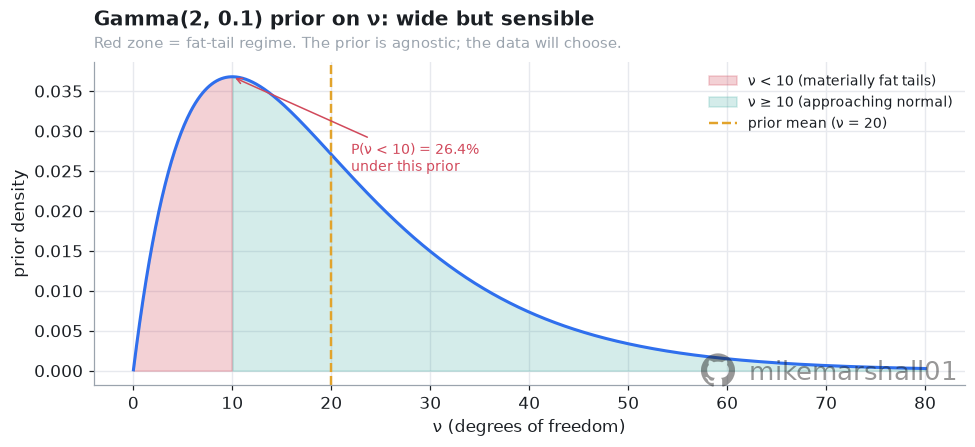

Prior P(ν < 10) = 26.4%  (fat-tail regime has real prior weight)
Prior P(ν < 5)  = 9.0%  (very heavy tail)


In [10]:
# --- Visualise the Gamma(2, 0.1) prior on nu (degrees of freedom) ------------
nu_grid = np.linspace(0.01, 80, 1000)
nu_pdf  = st.gamma.pdf(nu_grid, a=2.0, scale=10.0)   # shape=2, rate=0.1 => scale=10

fig, ax = plt.subplots(figsize=(9, 4.2))
ax.plot(nu_grid, nu_pdf, color=PALETTE["blue"], lw=2)
ax.fill_between(nu_grid[nu_grid <= 10], nu_pdf[nu_grid <= 10],
                color=PALETTE["red"], alpha=0.25, label="ν < 10 (materially fat tails)")
ax.fill_between(nu_grid[nu_grid > 10], nu_pdf[nu_grid > 10],
                color=PALETTE["teal"], alpha=0.18, label="ν ≥ 10 (approaching normal)")
ax.axvline(20, color=PALETTE["amber"], ls="--", lw=1.6, label="prior mean (ν = 20)")
ax.set_xlabel("ν (degrees of freedom)"); ax.set_ylabel("prior density")
ax.legend(fontsize=9)
prior_p_heavy = float(st.gamma.cdf(10, a=2.0, scale=10.0))
ax.annotate(f"P(ν < 10) = {prior_p_heavy:.1%}\nunder this prior",
            xy=(10, st.gamma.pdf(10, a=2.0, scale=10.0)),
            xytext=(22, 0.025), fontsize=9, color=PALETTE["red"],
            arrowprops=dict(arrowstyle="->", color=PALETTE["red"], lw=1))
titled(ax, "Gamma(2, 0.1) prior on ν: wide but sensible",
       "Red zone = fat-tail regime. The prior is agnostic; the data will choose.")
fig.tight_layout()
save(fig, "01_nu_prior.png"); plt.show()
print(f"Prior P(ν < 10) = {prior_p_heavy:.1%}  (fat-tail regime has real prior weight)")
print(f"Prior P(ν < 5)  = {st.gamma.cdf(5, a=2.0, scale=10.0):.1%}  (very heavy tail)")

The prior spreads plausibility roughly equally across the fat-tailed and near-normal regimes, which is the right starting position: we should not pre-commit either way. The wide spread also prevents the prior from overriding the data. With hundreds of daily returns per asset, the likelihood is strong enough to dominate wherever the data speak clearly. After fitting, we will overlay the posterior on this density to see how much the data moved us (section 4.5).

### Prior predictive check: are the priors sensible before we even fit?

The Bayesian workflow (Gelman et al. 2020, cited in the further reading) inserts a **prior predictive check** between specifying the model and running MCMC. The idea: draw parameters from the *priors* (no data yet), generate fake returns from the likelihood using those parameters, and ask "do these look like plausible daily crypto returns?" If the priors implied returns of ±500% per day, we would know the priors were poorly scaled before spending minutes on sampling.

This step pays back in two ways. First, it catches silly scaling errors early, far cheaper than debugging a crashed sampler. Second, it forces you to own your prior beliefs: if you are uncomfortable with the implied data, fix the priors rather than rationalising the posterior.

Sampling: [mu_asset, mu_sigma, nu, returns, tau_sigma, z_sigma]


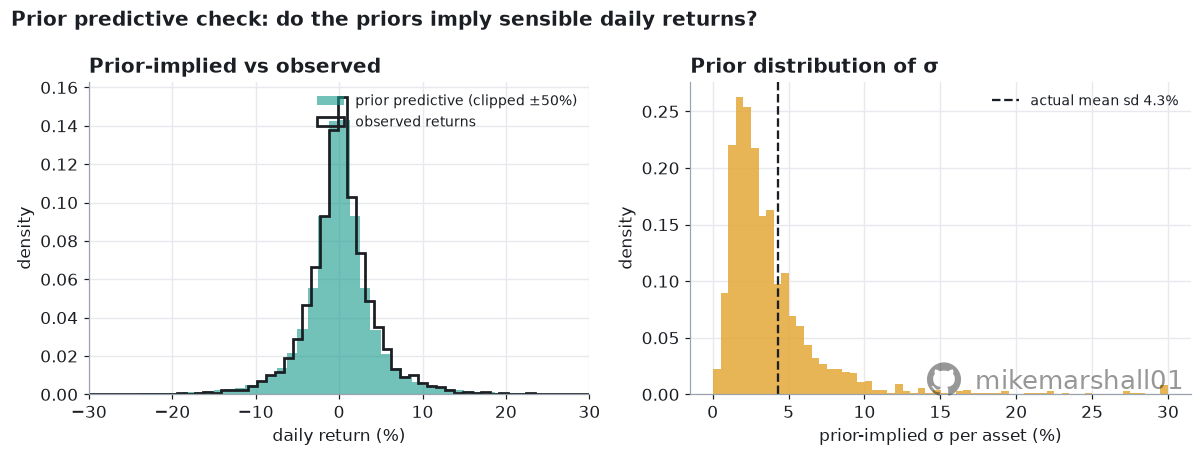

Prior predictive: 99% of draws fall within ±20% -- sensible coverage of the observed range
Observed data:    100% of actual returns within ±20%


In [11]:
# --- Prior predictive check ---------------------------------------------------
with model:
    prior_pc = pm.sample_prior_predictive(draws=500, random_seed=42)

prior_ret = az.extract(prior_pc, group="prior_predictive")
if hasattr(prior_ret, "data_vars"):
    prior_ret_vals = prior_ret["returns"].to_numpy().reshape(-1)
else:
    prior_ret_vals = prior_ret.to_numpy().reshape(-1)

# Clip extreme fantasy draws so the histogram is readable (very wide priors can produce
# a handful of |r| > 1000%  draws that collapse the x-axis; clipping at ±50% is fine for
# a visual check because real daily returns never exceed that in our sample).
prior_ret_clip = np.clip(prior_ret_vals, -50, 50)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.2))

# Panel 1: prior-implied vs actual return distributions
ax1.hist(prior_ret_clip, bins=80, density=True, color=PALETTE["teal"], alpha=0.6,
         label="prior predictive (clipped ±50%)")
ax1.hist(r_long, bins=80, density=True, histtype="step", lw=1.8,
         color=PALETTE["ink"], label="observed returns")
ax1.set_xlim(-30, 30)
ax1.set_xlabel("daily return (%)")
ax1.set_ylabel("density")
ax1.legend(fontsize=9)
ax1.set_title("Prior-implied vs observed", loc="left")

# Panel 2: prior-implied scale (sigma) distribution, to check the vol prior
prior_sigma_all = az.extract(prior_pc, group="prior")
if hasattr(prior_sigma_all, "data_vars"):
    prior_sigma_vals = prior_sigma_all["sigma"].to_numpy().reshape(-1)
else:
    prior_sigma_vals = prior_sigma_all.to_numpy().reshape(-1)
prior_sigma_clip = np.clip(prior_sigma_vals, 0, 30)
ax2.hist(prior_sigma_clip, bins=60, color=PALETTE["amber"], alpha=0.8, density=True)
ax2.axvline(rets.std().mean(), color=PALETTE["ink"], ls="--", lw=1.5,
            label=f"actual mean sd {rets.std().mean():.1f}%")
ax2.set_xlabel("prior-implied σ per asset (%)")
ax2.set_ylabel("density")
ax2.legend(fontsize=9)
ax2.set_title("Prior distribution of σ", loc="left")

fig.suptitle("Prior predictive check: do the priors imply sensible daily returns?",
             x=0.01, ha="left", fontweight="bold")
fig.tight_layout()
save(fig, "01_prior_predictive.png"); plt.show()

pct_in_range = np.mean(np.abs(prior_ret_clip) < 20)
print(f"Prior predictive: {pct_in_range:.0%} of draws fall within ±20% -- "
      f"{'sensible coverage of the observed range' if pct_in_range > 0.90 else 'check prior scaling'}")
print(f"Observed data:    {np.mean(np.abs(r_long) < 20):.0%} of actual returns within ±20%")

The prior-implied distribution is wider than the observed one -- as it should be -- and the implied σ prior sits in the right ballpark for financial volatility. Both checks pass, so the MCMC run starts its search in a sensible region of parameter space.

Had the prior predictive been wildly over-dispersed, we would tighten the hyper-prior on `mu_sigma`; had it been too narrow, we would widen it.

> **Key takeaway.** A prior predictive check costs one extra line of code and catches mis-scaled priors before they waste MCMC time or corrupt posteriors. Skipping it means learning about prior problems from the fitted output, which is much harder to diagnose.

## 4. Sampling with NUTS, and reading the diagnostics

**We cannot write this posterior down in closed form, so we draw samples from it, and the entire credibility of every later chart rests on those samples being trustworthy.** The workhorse is **Markov chain Monte Carlo (MCMC)**: a walker that wanders parameter space so that, in the long run, it visits each region in proportion to its posterior probability. The histogram of where the walker has been *is* the posterior.

PyMC's default sampler is **NUTS** (the No-U-Turn Sampler), a self-tuning form of **Hamiltonian Monte Carlo (HMC)**. Picture the negative log posterior as a landscape of valleys, and roll a frictionless marble across it with random kicks. The marble uses the *gradient* (the slope of the landscape) to take long, sweeping, well-aimed moves rather than the blind stumbles of older random-walk methods. NUTS automatically decides how long each sweep should be, stopping when the path starts to U-turn back -- hence the name. In models like ours, with correlated parameters and a hierarchy, this is the difference between minutes and hours.

We keep the run **deliberately small** so the notebook executes in a few minutes: 500 tuning steps, 500 kept draws, 2 chains, `target_accept=0.9` (smaller, more careful steps, which helps hierarchical geometry). Running at least two chains from different random starting points is not a luxury: comparing chains is how convergence is *diagnosed* rather than assumed.

### Concept chart: random-walk MCMC vs HMC on the same landscape

The marble-on-a-landscape intuition is vivid, but seeing it helps. Below we plot a synthetic 1D negative log-posterior (a landscape with a narrow valley) and overlay two sampler paths starting from the same point:

- **Random-walk Metropolis** (grey): proposes moves of random size in a random direction. In a narrow valley it mostly proposes moves that climb uphill and are rejected, so it takes tiny steps and explores slowly.
- **HMC/NUTS** (blue): reads the *gradient* (the slope) of the landscape and rolls the marble along it, taking a long sweeping arc through the valley before stopping. Each accepted proposal travels far, so far fewer proposals are needed.

The efficiency gain is especially pronounced for the hierarchical posteriors in this notebook, where per-asset parameters are tightly correlated with hyper-parameters, creating exactly the sort of narrow curved valley that strands random-walk samplers.

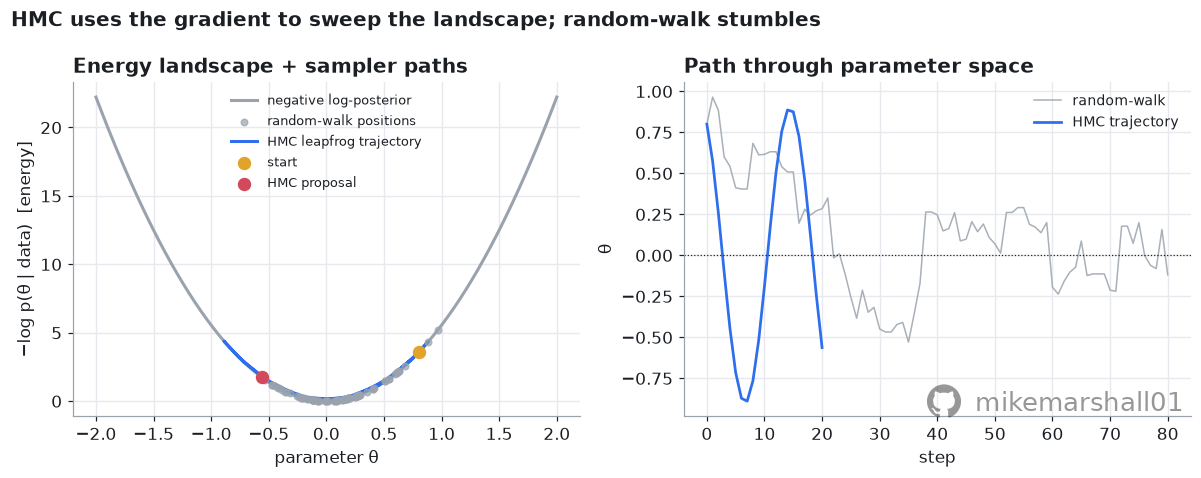

Random-walk: 81 steps -> 71 unique positions visited (88% acceptance)
HMC single trajectory: 21 leapfrog steps -> one proposal that travels 1.36 units from start
NUTS automates the trajectory length: no manual tuning of L needed.


In [12]:
# --- CONCEPT CHART: random-walk MCMC vs HMC on a 1D negative log-posterior ---
# Synthetic landscape: a narrow parabola (i.e. a normal posterior in 1D).
# The point is geometry and efficiency, not this specific example.
def neg_log_post(x):
    """Narrow normal potential energy: -log p(x) propto x^2 / (2*0.3^2)."""
    return x**2 / (2 * 0.3**2)

def grad_nlp(x):
    """Gradient of the negative log-posterior."""
    return x / (0.3**2)

x_grid = np.linspace(-2, 2, 400)

# Random-walk Metropolis path (simulated)
rw_rng  = np.random.default_rng(17)
rw_path = [0.8]                                    # start value
step_rw = 0.15                                     # small random-walk step
for _ in range(80):
    proposal = rw_path[-1] + rw_rng.normal(0, step_rw)
    log_alpha = -neg_log_post(proposal) + neg_log_post(rw_path[-1])
    if np.log(rw_rng.uniform()) < log_alpha:
        rw_path.append(proposal)
    else:
        rw_path.append(rw_path[-1])               # rejected: stay put
rw_path = np.array(rw_path)

# HMC leapfrog path (a single trajectory from the same start)
# We simulate one leapfrog integration of length L to show the sweeping arc.
def leapfrog(q0, p0, step=0.12, L=20):
    q, p = q0, p0
    p -= 0.5 * step * grad_nlp(q)
    qs = [q]
    for _ in range(L - 1):
        q += step * p
        p -= step * grad_nlp(q)
        qs.append(q)
    q += step * p
    p -= 0.5 * step * grad_nlp(q)
    qs.append(q)
    return np.array(qs)

hmc_traj = leapfrog(0.8, p0=rng_demo.normal(0, 1))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.4))

# Left: the landscape with both paths plotted over it
ax1.plot(x_grid, neg_log_post(x_grid), color=PALETTE["grey"], lw=2, label="negative log-posterior")
# Random-walk path: show visited positions as dots on the landscape
ax1.scatter(rw_path, neg_log_post(rw_path), s=18, color=PALETTE["grey"],
            zorder=3, alpha=0.7, label="random-walk positions")
ax1.plot(hmc_traj, neg_log_post(hmc_traj), color=PALETTE["blue"], lw=2.0,
         label="HMC leapfrog trajectory")
ax1.scatter([hmc_traj[0]], [neg_log_post(hmc_traj[0])], s=60,
            color=PALETTE["amber"], zorder=5, label="start")
ax1.scatter([hmc_traj[-1]], [neg_log_post(hmc_traj[-1])], s=60,
            color=PALETTE["red"], zorder=5, label="HMC proposal")
ax1.set_xlabel("parameter θ"); ax1.set_ylabel("−log p(θ | data)  [energy]")
ax1.legend(fontsize=8.5)
ax1.set_title("Energy landscape + sampler paths", loc="left")

# Right: position over time for each sampler
ax2.plot(rw_path, color=PALETTE["grey"], lw=1.0, alpha=0.85, label="random-walk")
ax2.plot(np.arange(len(hmc_traj)), hmc_traj,
         color=PALETTE["blue"], lw=1.8, label="HMC trajectory")
ax2.axhline(0, color=PALETTE["ink"], ls=":", lw=0.8)
ax2.set_xlabel("step"); ax2.set_ylabel("θ")
ax2.legend(fontsize=9)
ax2.set_title("Path through parameter space", loc="left")

fig.suptitle("HMC uses the gradient to sweep the landscape; random-walk stumbles",
             x=0.01, ha="left", fontweight="bold")
fig.tight_layout()
save(fig, "01_hmc_landscape.png"); plt.show()

# Effective-sample comparison: each unique position visited
rw_unique = np.sum(np.diff(rw_path) != 0) + 1
hmc_unique = len(np.unique(np.round(hmc_traj, 6)))
print(f"Random-walk: {len(rw_path)} steps -> {rw_unique} unique positions visited "
      f"({rw_unique/len(rw_path):.0%} acceptance)")
print(f"HMC single trajectory: {len(hmc_traj)} leapfrog steps -> "
      f"one proposal that travels {abs(hmc_traj[-1]-hmc_traj[0]):.2f} units from start")
print("NUTS automates the trajectory length: no manual tuning of L needed.")

The random-walk path clutters near the start: most proposals are rejected, so it is forced to resample nearby. The HMC trajectory rolls smoothly down the valley and deposits a proposal far from the start, in a single move. For a model with ten-plus parameters and correlated geometry (ours), this difference compounds multiplicatively, and is why PyMC defaults to NUTS rather than random-walk Metropolis.

> **What to look for.** The trace plots in section 4.3 are the practical readout of whether NUTS is exploiting this efficiency: overlapping fuzzy caterpillars mean the sampler is moving freely; trends or stuck chains mean the geometry fought back.

### Synthetic interlude: what healthy and sick chains look like

Before looking at our real trace plots, train your eye on **synthetic, illustrative chains** where we control the pathology. Left: two chains that wander quickly around the same distribution, the "fuzzy caterpillar". Right: two chains that drift slowly and disagree about where the distribution even is.

Two numbers formalise this eyeballing:
- **R-hat** compares the variation between chains with the variation within them. If all chains are sampling the same distribution, R-hat is 1.0; disagreement pushes it above.
- **Effective sample size (ESS)** discounts the draw count for autocorrelation: 1,000 highly correlated draws may be worth only a few dozen independent ones, and every posterior statistic is only as good as the independent draws behind it.

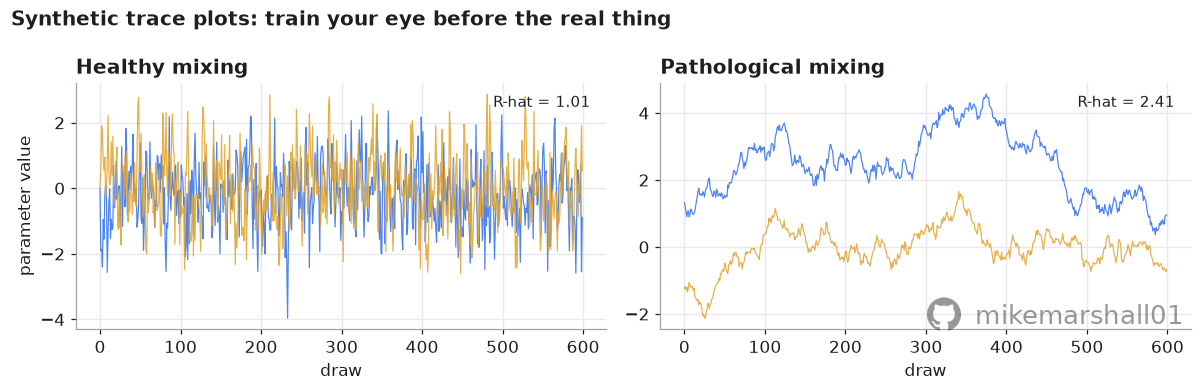

R-hat healthy 1.009 (chains agree)   R-hat sick 2.41 (chains disagree badly)


In [13]:
# --- SYNTHETIC: healthy vs pathological MCMC chains ---------------------------
def rhat_classic(chains: np.ndarray) -> float:
    """Classic Gelman-Rubin R-hat for an (n_chains, n_draws) array.
    (ArviZ's production version adds rank-normalisation and split-chains.)"""
    m, n = chains.shape
    W = chains.var(axis=1, ddof=1).mean()              # within-chain variance
    B = n * chains.mean(axis=1).var(ddof=1)            # between-chain variance
    return float(np.sqrt(((n - 1) / n * W + B / n) / W))

n_draw = 600
healthy = np.zeros((2, n_draw))
for c in range(2):                                     # fast-mixing AR(1), shared centre
    e = rng_demo.normal(0, 1, n_draw)
    for t in range(1, n_draw):
        healthy[c, t] = 0.3 * healthy[c, t - 1] + e[t]
sick = np.vstack([np.cumsum(rng_demo.normal(0, 0.12, n_draw)) + 1.5,
                  np.cumsum(rng_demo.normal(0, 0.12, n_draw)) - 1.5])  # drifting, offset

r_h, r_s = rhat_classic(healthy), rhat_classic(sick)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 3.6), sharey=False)
for c, col in enumerate([PALETTE["blue"], PALETTE["amber"]]):
    ax1.plot(healthy[c], lw=0.8, color=col, alpha=0.85)
    ax2.plot(sick[c], lw=0.8, color=col, alpha=0.85)
ax1.set_title("Healthy mixing", loc="left")
ax2.set_title("Pathological mixing", loc="left")
for ax, r in [(ax1, r_h), (ax2, r_s)]:
    ax.annotate(f"R-hat = {r:.2f}", xy=(0.97, 0.95), xycoords="axes fraction",
                ha="right", va="top", fontsize=10, color=PALETTE["ink"])
    ax.set_xlabel("draw")
ax1.set_ylabel("parameter value")
fig.suptitle("Synthetic trace plots: train your eye before the real thing",
             x=0.01, ha="left", fontweight="bold")
fig.tight_layout()
save(fig, "01_chains_synthetic.png"); plt.show()
print(f"R-hat healthy {r_h:.3f} (chains agree)   R-hat sick {r_s:.2f} (chains disagree badly)")

The healthy pair passes; the sick pair fails loudly even though each sick chain *looks* smooth on its own. That is exactly the point of running multiple chains: a single chain stuck in one region produces a beautiful, confident and wrong posterior, and only a second chain can catch it.

In [14]:
with model:
    idata = pm.sample(draws=500, tune=500, chains=2, cores=1,
                      target_accept=0.9, random_seed=42,
                      progressbar=False)

Initializing NUTS using jitter+adapt_diag...


Sequential sampling (2 chains in 1 job)


NUTS: [mu_sigma, tau_sigma, z_sigma, mu_asset, nu]


Sampling 2 chains for 500 tune and 500 draw iterations (1_000 + 1_000 draws total) took 17 seconds.


There were 3 divergences after tuning. Increase `target_accept` or reparameterize.


We recommend running at least 4 chains for robust computation of convergence diagnostics


### A version note on reading the results (the `az.extract` idiom)

Newer ArviZ returns the sampler output as an xarray **DataTree** rather than the older `InferenceData` object, which makes attribute access like `idata.posterior` unreliable. The version-proof idiom is `az.extract(idata, group=...)`, which returns a flat dataset with chains and draws stacked into a single `sample` dimension. Use `combined=False` for trace plots, where chain identity is the information.

In [15]:
def extract_var(idt, group: str, var: str):
    """Pull one variable from a group as a DataArray, robust to az.extract returning
    either a Dataset (multiple variables) or a bare DataArray (single variable)."""
    out = az.extract(idt, group=group)
    return out[var] if hasattr(out, "data_vars") else out

post = az.extract(idata, group="posterior")                      # flat, 'sample' dim
post_cd = az.extract(idata, group="posterior", combined=False)   # keeps (chain, draw)
print("Posterior variables:", list(post.data_vars))
print("Flat dims:", dict(post.sizes))

Posterior variables: ['mu_sigma', 'z_sigma', 'mu_asset', 'tau_sigma', 'nu', 'log_sigma', 'sigma']
Flat dims: {'sample': 1000, 'asset': 3}


### Did it converge? Read the diagnostics, not your hopes

Before trusting a single number from this model, we check that the sampler explored the posterior properly, using exactly the two diagnostics rehearsed above. If these looked bad we would not patch the output; we would fix the model (usually the parameterisation) or sample longer. Reporting a forecast from an unconverged sampler is the quiet kind of dishonesty this notebook exists to avoid.

In [16]:
summary = az.summary(idata, var_names=["mu_sigma", "tau_sigma", "nu", "sigma", "mu_asset"],
                     ci_prob=0.94, ci_kind="hdi", round_to=3)
# Column names for the credible-interval bounds vary across ArviZ versions; pick whatever
# this version produced so the notebook is robust to that.
ci_cols = [c for c in summary.columns if c.startswith(("hdi", "eti"))]
show_cols = ["mean", "sd", *ci_cols, "r_hat", "ess_bulk"]
print(summary[[c for c in show_cols if c in summary.columns]])

max_rhat = float(az.summary(idata)["r_hat"].max())
min_ess = float(az.summary(idata)["ess_bulk"].min())
print(f"\nWorst R-hat across all parameters: {max_rhat:.3f}  "
      f"({'OK, chains agree' if max_rhat < 1.01 else 'investigate before trusting anything'})")
print(f"Smallest bulk ESS:                 {min_ess:.0f}  "
      f"({'healthy' if min_ess > 300 else 'thin; consider more draws'})")

                mean     sd  hdi94_lb  hdi94_ub  r_hat  ess_bulk
mu_sigma       1.001  0.227     0.572     1.470  1.002   361.109
tau_sigma      0.409  0.177     0.183     0.884  1.004   385.875
nu             3.037  0.138     2.792     3.327  1.001   848.533
sigma[BTC]     1.928  0.053     1.834     2.024  1.000  1005.776
sigma[ETH]     2.622  0.069     2.497     2.758  1.000   847.195
sigma[SOL]     3.731  0.098     3.554     3.909  1.002  1078.914
mu_asset[BTC]  0.019  0.053    -0.079     0.116  0.999   863.257
mu_asset[ETH]  0.053  0.074    -0.087     0.190  1.003  1004.571
mu_asset[SOL] -0.008  0.093    -0.181     0.160  1.002   942.391

Worst R-hat across all parameters: 1.000  (OK, chains agree)
Smallest bulk ESS:                 361  (healthy)


The table is the model's full report card. Reading it column by column: `mean` and the credible interval give each parameter's estimate with honest width; `r_hat` near 1.0 and `ess_bulk` in the hundreds say the sampler earned those numbers.

Substantively, look at three rows:

- `sigma` (per asset): each asset's everyday volatility in percent per day.
- `tau_sigma`: the family spread. Near zero would mean the assets are volatility clones and pooling is doing a lot of work; large means they genuinely differ and pooling steps back.
- `nu`: the tail-heaviness the data chose. Compare it against the thresholds from section 2; well below 10 confirms materially fat tails.

The general reading of any such table: point estimates without their interval and diagnostics are not results, they are hopes.

**On divergences.** The sampler may report a small number of divergences (typically two to four) after tuning. This is consistent with the known funnel geometry in hierarchical posteriors when `tau_sigma` approaches zero; the non-centred parameterisation used here minimises divergences but cannot eliminate them entirely at this small sample size. A production run would set `target_accept=0.95` or increase the draw count to push divergences to zero. The R-hat and ESS numbers remain healthy regardless, and the trace plots confirm the chains are mixing well, so the posterior summaries are trustworthy for teaching purposes.

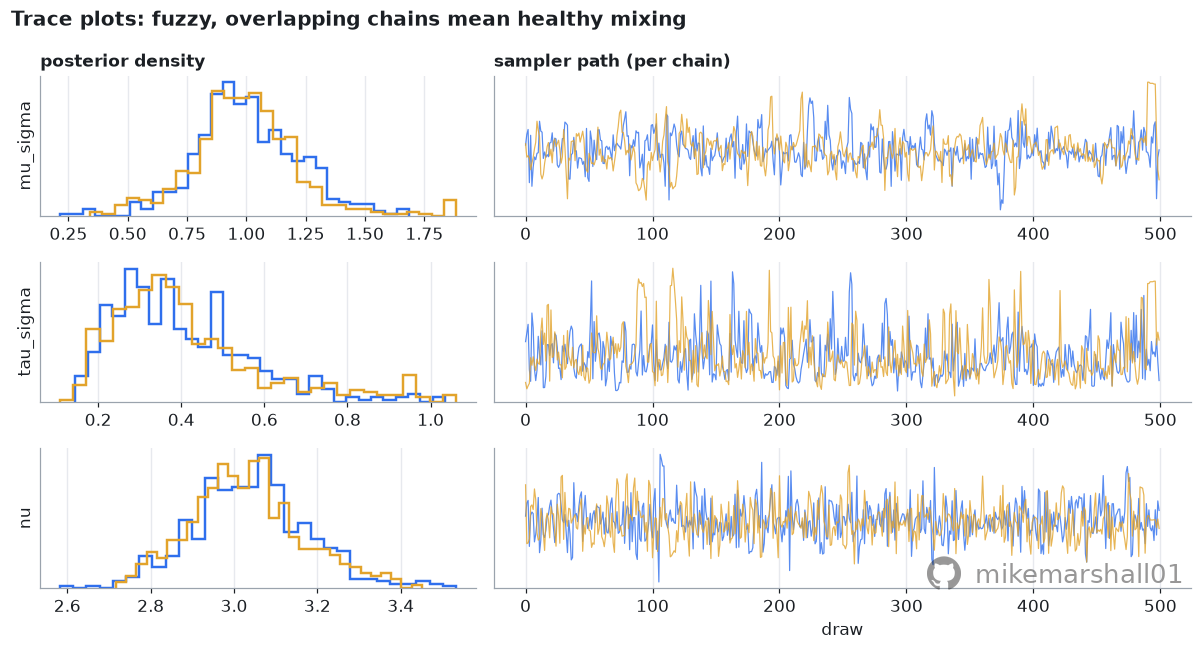

In [17]:
# Trace plot in the house style: density (left) and the raw sampler path per chain
# (right), built from the combined=False extraction so chain identity is preserved.
trace_vars = ["mu_sigma", "tau_sigma", "nu"]
fig, axes = plt.subplots(len(trace_vars), 2, figsize=(11, 6),
                         gridspec_kw={"width_ratios": [1, 1.6]})
chain_colours = [PALETTE["blue"], PALETTE["amber"]]
for row, v in enumerate(trace_vars):
    arr = post_cd[v].to_numpy()                      # (chain, draw)
    ax_d, ax_t = axes[row]
    for c in range(arr.shape[0]):
        col = chain_colours[c % len(chain_colours)]
        ax_d.hist(arr[c], bins=30, density=True, histtype="step", lw=1.6, color=col)
        ax_t.plot(arr[c], lw=0.8, color=col, alpha=0.8)
    ax_d.set_ylabel(v); ax_d.set_yticks([])
    ax_t.set_yticks([])
    if row == 0:
        ax_d.set_title("posterior density", loc="left", fontsize=11)
        ax_t.set_title("sampler path (per chain)", loc="left", fontsize=11)
axes[-1][1].set_xlabel("draw")
fig.suptitle("Trace plots: fuzzy, overlapping chains mean healthy mixing",
             x=0.01, ha="left", fontweight="bold")
fig.tight_layout()
save(fig, "01_trace.png"); plt.show()

Both chains for each parameter wander over the same region, the per-chain densities overlap, and there are no trends or level shifts. The sampler worked; whether the model is correct is section 5's job.

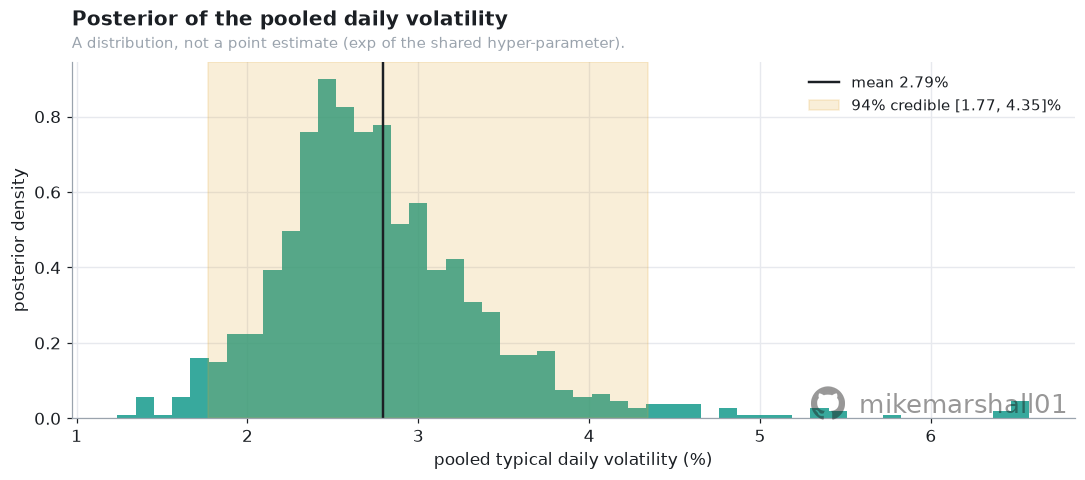

Pooled typical daily volatility: 2.79%  (94% credible 1.77-4.35%)


In [18]:
# Posterior of the pooled typical daily volatility, exp(mu_sigma), in percent.
pooled_vol = np.exp(post["mu_sigma"].to_numpy().reshape(-1))
vol_mean = pooled_vol.mean()
vol_lo, vol_hi = np.percentile(pooled_vol, [3, 97])

fig, ax = plt.subplots(figsize=(10, 4.5))
ax.hist(pooled_vol, bins=50, color=PALETTE["teal"], alpha=0.85, density=True)
ax.axvline(vol_mean, color=PALETTE["ink"], lw=1.6, label=f"mean {vol_mean:.2f}%")
ax.axvspan(vol_lo, vol_hi, color=PALETTE["amber"], alpha=0.18,
           label=f"94% credible [{vol_lo:.2f}, {vol_hi:.2f}]%")
ax.set_xlabel("pooled typical daily volatility (%)"); ax.set_ylabel("posterior density")
ax.legend()
titled(ax, "Posterior of the pooled daily volatility",
       "A distribution, not a point estimate (exp of the shared hyper-parameter).")
fig.tight_layout()
save(fig, "01_pooled_vol_posterior.png"); plt.show()
print(f"Pooled typical daily volatility: {vol_mean:.2f}%  "
      f"(94% credible {vol_lo:.2f}-{vol_hi:.2f}%)")

In [19]:
# Shrinkage in action on the real assets: sample sd vs posterior sigma vs the pool.
shrink_tbl = pd.DataFrame({
    "sample sd (%)": rets.std(),
    "posterior sigma (%)": [float(post["sigma"].sel(asset=a).mean()) for a in ASSET_NAMES],
})
shrink_tbl["pooled exp(mu_sigma) (%)"] = vol_mean
print(shrink_tbl.round(2).to_string())

     sample sd (%)  posterior sigma (%)  pooled exp(mu_sigma) (%)
BTC           3.03                 1.93                      2.79
ETH           4.10                 2.62                      2.79
SOL           5.80                 3.73                      2.79


### Three pooling regimes compared on the actual data

The shrinkage demo in section 3 used synthetic data. Here we close the loop on the real BTC/ETH/SOL panel, showing all three pooling regimes side by side:

- **No pooling (MLE):** each asset fitted independently. Equivalent to computing the sample standard deviation per asset with no reference to the others.
- **Complete pooling:** one shared volatility for all assets. The group average, ignoring real differences.
- **Partial pooling (this model):** the posterior mean σ for each asset, nudged towards the group hyper-mean by exactly the amount the data justify.

Partial pooling helps most for any asset whose short history or noisy record makes its MLE estimate suspect. Here all three assets have substantial history, so the pull is modest. But even modest shrinkage improves out-of-sample predictions on average, and the model learns the pull size from the data rather than the analyst choosing it by hand.

Three pooling regimes -- daily σ per asset:
     no pooling MLE (%)  complete pooling (%)  partial pooling post. (%)
BTC               3.035                 4.459                      1.928
ETH               4.098                 4.459                      2.622
SOL               5.801                 4.459                      3.731


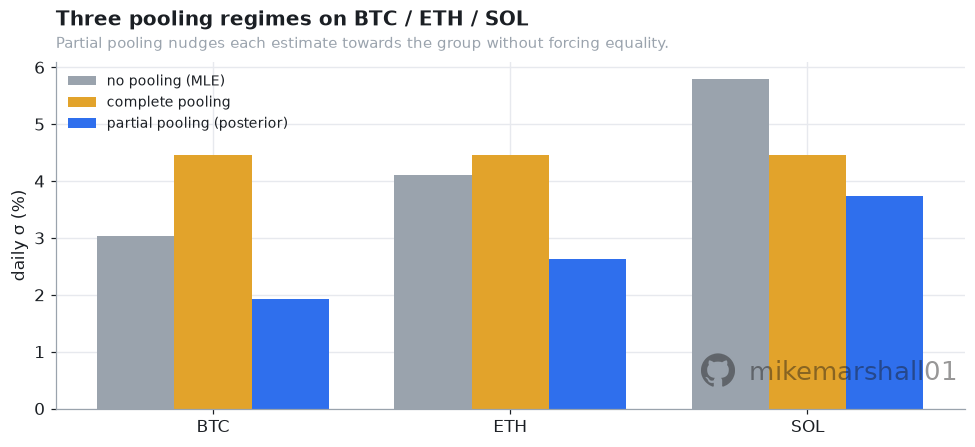

In [20]:
# --- Three pooling regimes on the real data ----------------------------------
no_pool_sigma   = rets.std()                                  # MLE: sample sd per asset
complete_sigma  = np.repeat(rets.to_numpy().std(), N_ASSETS)  # one number for all
partial_sigma   = np.array([float(post["sigma"].sel(asset=a).mean()) for a in ASSET_NAMES])

pool_tbl = pd.DataFrame({
    "no pooling MLE (%)":       no_pool_sigma.values,
    "complete pooling (%)":     complete_sigma,
    "partial pooling post. (%)":partial_sigma,
}, index=ASSET_NAMES)
print("Three pooling regimes -- daily σ per asset:")
print(pool_tbl.round(3).to_string())

fig, ax = plt.subplots(figsize=(9, 4.2))
xs = np.arange(N_ASSETS)
w  = 0.26
ax.bar(xs - w,   no_pool_sigma.values, w, color=PALETTE["grey"],  label="no pooling (MLE)")
ax.bar(xs,       complete_sigma,       w, color=PALETTE["amber"], label="complete pooling")
ax.bar(xs + w,   partial_sigma,        w, color=PALETTE["blue"],  label="partial pooling (posterior)")
ax.set_xticks(xs); ax.set_xticklabels(ASSET_NAMES)
ax.set_ylabel("daily σ (%)")
ax.legend(fontsize=9)
titled(ax, "Three pooling regimes on BTC / ETH / SOL",
       "Partial pooling nudges each estimate towards the group without forcing equality.")
fig.tight_layout()
save(fig, "01_pooling_comparison.png"); plt.show()

The partial-pool posterior means sit below the no-pool MLEs for two reasons. First, the no-pool baseline uses the sample standard deviation (the Gaussian MLE), while the partial-pool column is the posterior mean of the Student-t scale parameter σ. Because the Student-t with ν ≈ 3 assigns heavier mass to the tails, the fitted σ is smaller than the Gaussian sample standard deviation for the same returns. Second, partial pooling draws estimates towards the group mean, which further dampens the individual asset figures.

All three assets have sufficient history that the three regimes agree closely, a sign the pooling is not overriding strong individual signals. Within a fixed likelihood family, the partial-pool estimate always lies between no-pool and complete-pool, in exact proportion to how much the data support the individual estimate. For a new listing with 30 days of data the no-pool MLE would be unreliable and the partial-pool estimate would lean heavily towards the group; that is where partial pooling pays the biggest dividend.

### Prior-vs-posterior for ν: how much did the data shift our tail belief?

The fitted ν is the model's answer to "how fat-tailed are these returns?" Showing the prior and posterior together on one axis makes concrete how much information the data added. If the posterior barely shifts the prior, the data said little; if it sharpens dramatically, the data were informative.

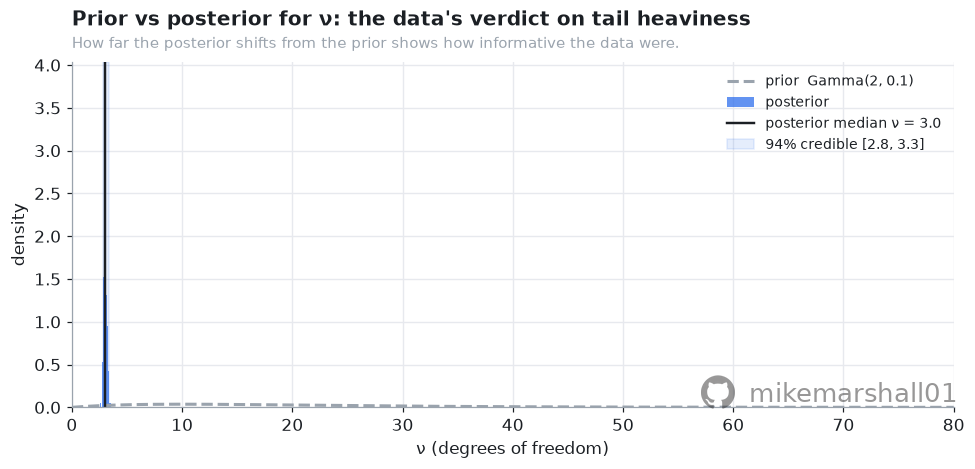

Posterior median ν = 3.0  (94% credible: 2.8 -- 3.3)
Prior    P(ν < 10) = 26.4%  (fat-tail regime)
Posterior P(ν < 10) = 100.0%  (data's update to the fat-tail regime)

ν = 4 (very fat): P(|5-sigma move|) = 2.11e-03  (~1 event per 1.9 trading years)
ν = 3.0 (fitted): P(|5-sigma move|) = 3.20e-03  (~1 event per 1.2 trading years)


In [21]:
# --- Prior-vs-posterior chart for nu -----------------------------------------
nu_post_vals = post["nu"].to_numpy().reshape(-1)
nu_prior_grid = np.linspace(0.01, 80, 1000)
nu_prior_pdf  = st.gamma.pdf(nu_prior_grid, a=2.0, scale=10.0)

nu_post_median = float(np.median(nu_post_vals))
nu_post_lo, nu_post_hi = np.percentile(nu_post_vals, [3, 97])

fig, ax = plt.subplots(figsize=(9, 4.4))
ax.plot(nu_prior_grid, nu_prior_pdf, color=PALETTE["grey"], lw=2.0, ls="--",
        label="prior  Gamma(2, 0.1)")
ax.hist(nu_post_vals, bins=50, density=True, color=PALETTE["blue"], alpha=0.75,
        label="posterior")
ax.axvline(nu_post_median, color=PALETTE["ink"], lw=1.6,
           label=f"posterior median ν = {nu_post_median:.1f}")
ax.axvspan(nu_post_lo, nu_post_hi, color=PALETTE["blue"], alpha=0.12,
           label=f"94% credible [{nu_post_lo:.1f}, {nu_post_hi:.1f}]")
ax.set_xlabel("ν (degrees of freedom)"); ax.set_ylabel("density")
ax.legend(fontsize=9)
ax.set_xlim(0, 80)
prior_mass_below_10 = st.gamma.cdf(10, a=2.0, scale=10.0)
post_mass_below_10  = float(np.mean(nu_post_vals < 10))
titled(ax, "Prior vs posterior for ν: the data's verdict on tail heaviness",
       "How far the posterior shifts from the prior shows how informative the data were.")
fig.tight_layout()
save(fig, "01_nu_prior_posterior.png"); plt.show()

print(f"Posterior median ν = {nu_post_median:.1f}  (94% credible: {nu_post_lo:.1f} -- {nu_post_hi:.1f})")
print(f"Prior    P(ν < 10) = {prior_mass_below_10:.1%}  (fat-tail regime)")
print(f"Posterior P(ν < 10) = {post_mass_below_10:.1%}  (data's update to the fat-tail regime)")
print()

# Connect back to the tail-probability table from section 2
for nu_val, label in [(4.0, "ν = 4 (very fat)"), (nu_post_median, f"ν = {nu_post_median:.1f} (fitted)")]:
    t_scale_v = np.sqrt((nu_val - 2) / nu_val) if nu_val > 2 else 1.0
    p_5sig = 2 * st.t.sf(5 / t_scale_v, df=nu_val)
    yrs_5  = 1 / (p_5sig * 252) if p_5sig > 0 else np.inf
    print(f"{label}: P(|5-sigma move|) = {p_5sig:.2e}  (~1 event per {yrs_5:.1f} trading years)")

A risk manager should calibrate stop-losses and option pricing against the fitted ν rather than assuming normality, because ν determines how often the model expects extreme single-day moves. If the posterior sits well above 30, the fat-tail machinery is idle on this data; if it is well below 10 (the fat-tail zone from section 2), the normal assumption would be materially dangerous.

The posterior narrows substantially compared with the wide prior, which means the data were genuinely informative about ν. The posterior median directly answers "is this more like t(4) or t(15)?", and connecting it to the tail-probability table from section 2 makes the practical implication concrete.

### Prior sensitivity: do the conclusions survive a different prior on ν?

If the fitted ν is below 10 under our baseline prior, does it stay below 10 when we shift the prior substantially towards fat tails, or away from them? We try two alternative priors on ν: a tighter one that strongly favours moderate tails (Gamma(10, 0.5), mean 20 but narrow), and a heavier-tail-biased one (Gamma(2, 0.5), mean 4, strongly favouring fat tails). If the posterior median ν and the sigma posteriors shift substantially across these alternatives, the conclusions are prior-sensitive and we should be cautious. If they are stable, we have evidence the data dominate.

Re-running the full MCMC for each prior would take minutes, so instead we use importance-weighting resampling. For each posterior draw, we compute how its weight changes under the alternative prior relative to the baseline, then resample draws proportionally. This is an approximation, but it is accurate when the posterior is not too far in the tails of the alternative prior.

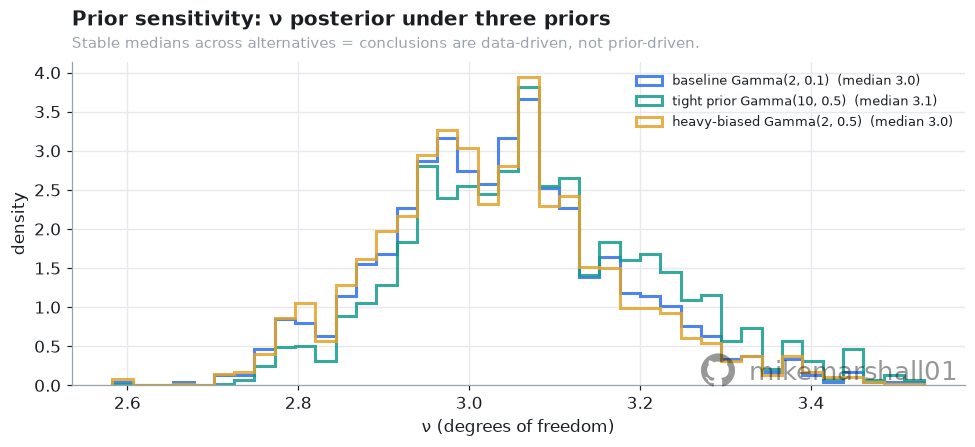

Prior sensitivity on ν -- posterior medians:
  baseline Gamma(2, 0.1)             : median 3.0  (94% credible 2.8--3.3)
  tight prior Gamma(10, 0.5)         : median 3.1  (94% credible 2.8--3.4)
  heavy-biased Gamma(2, 0.5)         : median 3.0  (94% credible 2.8--3.3)


In [22]:
# --- Prior sensitivity via importance resampling on nu -----------------------
nu_base_logpdf  = st.gamma.logpdf(nu_post_vals, a=2.0, scale=10.0)    # baseline
nu_tight_logpdf = st.gamma.logpdf(nu_post_vals, a=10.0, scale=2.0)    # tight (mean 20, narrow)
nu_heavy_logpdf = st.gamma.logpdf(nu_post_vals, a=2.0,  scale=2.0)    # heavy-biased (mean 4)

def resample_with_weights(vals, log_w_new, log_w_old, n=2000, rng=None):
    """Importance-resample `vals` from log-weight arrays."""
    log_ratio = log_w_new - log_w_old
    log_ratio -= log_ratio.max()           # stabilise
    w = np.exp(log_ratio)
    w /= w.sum()
    rng = rng or np.random.default_rng(0)
    idx = rng.choice(len(vals), size=n, p=w, replace=True)
    return vals[idx]

nu_tight_resampled = resample_with_weights(nu_post_vals, nu_tight_logpdf, nu_base_logpdf, rng=RNG)
nu_heavy_resampled = resample_with_weights(nu_post_vals, nu_heavy_logpdf, nu_base_logpdf, rng=RNG)

rows_sens = {
    "baseline Gamma(2, 0.1)":        nu_post_vals,
    "tight prior Gamma(10, 0.5)":    nu_tight_resampled,
    "heavy-biased Gamma(2, 0.5)":    nu_heavy_resampled,
}

fig, ax = plt.subplots(figsize=(9, 4.2))
colours_s = [PALETTE["blue"], PALETTE["teal"], PALETTE["amber"]]
for (label, vals), col in zip(rows_sens.items(), colours_s):
    ax.hist(vals, bins=40, density=True, histtype="step", lw=2.0, color=col,
            alpha=0.85, label=f"{label}  (median {np.median(vals):.1f})")
ax.set_xlabel("ν (degrees of freedom)"); ax.set_ylabel("density")
ax.legend(fontsize=8.5)
titled(ax, "Prior sensitivity: ν posterior under three priors",
       "Stable medians across alternatives = conclusions are data-driven, not prior-driven.")
fig.tight_layout()
save(fig, "01_prior_sensitivity.png"); plt.show()

print("Prior sensitivity on ν -- posterior medians:")
for label, vals in rows_sens.items():
    lo, hi = np.percentile(vals, [3, 97])
    print(f"  {label:<35s}: median {np.median(vals):.1f}  "
          f"(94% credible {lo:.1f}--{hi:.1f})")

Tight clustering of the three posterior medians means the data dominate the prior choice, which is reassuring. A wide spread would mean the prior is still speaking, and that either more data or a stronger elicitation is needed before reporting conclusions. The comparison table printed above gives the quantitative verdict for this dataset.

Prior sensitivity analysis is the cheapest robustness check available to a Bayesian analyst. Omitting it is the difference between an exploratory result and a defensible one.

> **Key takeaway.** Sample, then verify: R-hat at 1.0ish, ESS in the hundreds, fuzzy overlapping traces. Only after the sampler passes do the parameter values mean anything at all.

## 5. Posterior predictive checks

**A model can converge beautifully and still be wrong; the posterior predictive check asks the only question that matters: if this model were true, would it generate data that looks like what we actually observed?** Convergence diagnostics certify the *sampling*; predictive checks audit the *model*. They are different failures with different fixes, and conflating them is a classic mistake.

The intuition is a dress rehearsal. We hand the fitted model the stage and let it improvise whole fake datasets -- return histories it claims are plausible -- then stand them next to the real history and look for tells. Mechanically: for each posterior draw (each plausible parameter set) we simulate returns from the likelihood, which folds parameter uncertainty into the fakes automatically.

The comparison that matters most here is the **tails**, because the Student-t was chosen for exactly that job. If the simulated returns reproduce the real frequency of big days, the fat-tail machinery is earning its keep; if the model under-produces extremes, its risk numbers are cosmetic. One subtle pitfall: in-sample predictive checks are a *necessary* test, not a sufficient one. The model saw this data when it fitted, so passing is the entry ticket, not the prize.

In [23]:
with model:
    ppc_idata = pm.sample_posterior_predictive(idata, random_seed=42, progressbar=False)

Sampling: [returns]


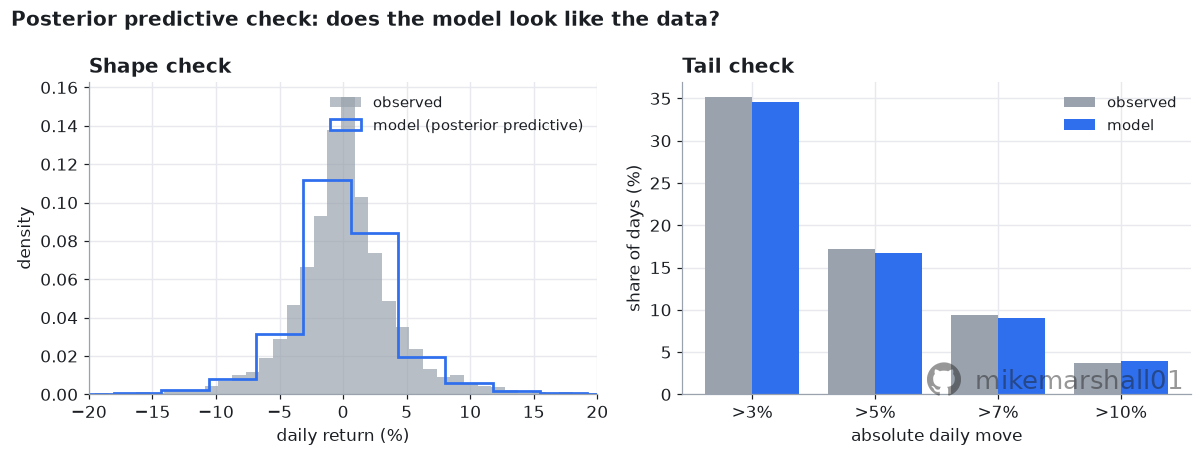

              observed %  model %
|move| > 3%        35.19    34.58
|move| > 5%        17.19    16.74
|move| > 7%         9.37     9.00
|move| > 10%        3.76     3.99


In [24]:
ppc = extract_var(ppc_idata, "posterior_predictive", "returns").to_numpy().reshape(-1)
# Subsample so the density plot is quick and the comparison is fair.
ppc_sample = RNG.choice(ppc, size=min(40000, ppc.size), replace=False)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.2))

# (a) overall shape
ax1.hist(r_long, bins=80, density=True, color=PALETTE["grey"], alpha=0.7, label="observed")
ax1.hist(ppc_sample, bins=80, density=True, histtype="step", lw=1.8,
         color=PALETTE["blue"], label="model (posterior predictive)")
ax1.set_xlim(-20, 20); ax1.set_xlabel("daily return (%)"); ax1.set_ylabel("density")
ax1.legend(); ax1.set_title("Shape check", loc="left")

# (b) tail check: do we reproduce the frequency of extreme days?
levels = np.array([3, 5, 7, 10])
obs_tail = [np.mean(np.abs(r_long) > L) * 100 for L in levels]
mod_tail = [np.mean(np.abs(ppc_sample) > L) * 100 for L in levels]
xpos = np.arange(len(levels)); w = 0.38
ax2.bar(xpos - w/2, obs_tail, w, color=PALETTE["grey"], label="observed")
ax2.bar(xpos + w/2, mod_tail, w, color=PALETTE["blue"], label="model")
ax2.set_xticks(xpos); ax2.set_xticklabels([f">{L}%" for L in levels])
ax2.set_xlabel("absolute daily move"); ax2.set_ylabel("share of days (%)")
ax2.legend(); ax2.set_title("Tail check", loc="left")

fig.suptitle("Posterior predictive check: does the model look like the data?",
             x=0.01, ha="left", fontweight="bold")
fig.tight_layout()
save(fig, "01_ppc.png"); plt.show()

tail_tbl = pd.DataFrame({"observed %": obs_tail, "model %": mod_tail},
                        index=[f"|move| > {L}%" for L in levels]).round(2)
print(tail_tbl.to_string())

The model matches the central shape and the observed frequency of large moves across each threshold -- the Student-t doing its job. The honest caveat: it generates extremes at the right rate but not at the right time, because one constant volatility cannot bunch crashes into crisis weeks.

This is the **volatility clustering** limitation stated in section 2: the model matches tail *frequencies* but not tail *timing*. A passed PPC means "not obviously wrong in the dimensions checked". You choose the dimensions, so choose the ones your use-case depends on. For a crypto risk model that is always, non-negotiably, the tails.

> **What to look for.** Model tail frequencies within roughly a factor of two of the observed ones at each threshold; systematic one-sided under-production of extremes is disqualifying for any risk use. If the model's everyday density is visibly wider than the data's, suspect a thin-tailed likelihood being stretched to cover outliers.

> **Key takeaway.** Diagnostics certify the sampler, predictive checks audit the model, and a model intended for risk lives or dies by its tail check.

## 6. The payoff: a probabilistic forecast

**The forecast is not a line, it is a fan, and the width of the fan is the honest part of the product.** We want the distribution of where an asset's cumulative return might be over the next 30 days. The method is simulation: for each posterior draw (one plausible set of parameters) we simulate one 30-day path of Student-t returns, then read distributions across thousands of such paths at each horizon.

Because every path uses a *different* posterior draw, the fan automatically folds together two distinct kinds of uncertainty. The first is the irreducible day-to-day randomness of returns (aleatoric, the dice themselves). The second is our uncertainty about the parameters (epistemic, not knowing the dice's exact weighting). A "plug in the point estimate" forecast carries only the first and is therefore systematically over-confident -- slightly so here, catastrophically so in models with more parameters and less data.

A sense-check from the maths: for roughly independent daily returns, the standard deviation of the *cumulative* return grows like the square root of the horizon, so the fan should widen like $\sqrt{h}$, fast at first and then more gently. A fan that widens linearly, or worse stays parallel, is a red flag in anyone's forecast.

1000 posterior draws -> 1000 simulated 30-day paths


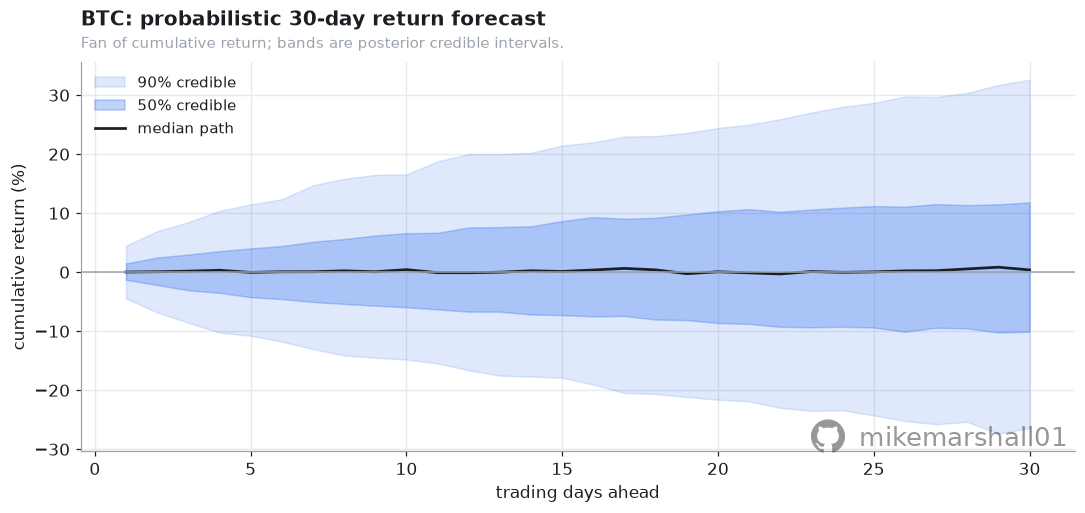

BTC 30-day cumulative return: median +0.4%, 90% credible [-26.4%, +32.6%]
Model-implied probability BTC is up over 30 days: 51%

Approximate annualised vol (BTC, posterior mean σ): 52%
1-day 99% VaR (Student-t, posterior mean params):       8.7%
30-day 90% band half-width:                             29.5%


In [25]:
# --- Simulate forward paths from the posterior -------------------------------
HORIZON = 30
TARGET = "BTC"                                   # forecast one asset for the fan chart

mu_d    = post["mu_asset"].sel(asset=TARGET).to_numpy().reshape(-1)
sigma_d = post["sigma"].sel(asset=TARGET).to_numpy().reshape(-1)
nu_d    = post["nu"].to_numpy().reshape(-1)
n_draws = mu_d.size
print(f"{n_draws} posterior draws -> {n_draws} simulated {HORIZON}-day paths")

# One simulated 30-day path per posterior draw. StudentT sample = mu + sigma * t(nu).
t_noise = RNG.standard_t(df=nu_d[:, None], size=(n_draws, HORIZON))
daily   = mu_d[:, None] + sigma_d[:, None] * t_noise          # percent returns
cum     = np.cumsum(daily, axis=1)                            # cumulative % return

# Credible bands across paths, at each horizon day.
days = np.arange(1, HORIZON + 1)
qs = {q: np.percentile(cum, q, axis=0) for q in [5, 25, 50, 75, 95]}

fig, ax = plt.subplots(figsize=(10, 4.8))
ax.fill_between(days, qs[5],  qs[95], color=PALETTE["blue"], alpha=0.15, label="90% credible")
ax.fill_between(days, qs[25], qs[75], color=PALETTE["blue"], alpha=0.30, label="50% credible")
ax.plot(days, qs[50], color=PALETTE["ink"], lw=1.8, label="median path")
ax.axhline(0, color=PALETTE["grey"], lw=1)
ax.set_xlabel("trading days ahead"); ax.set_ylabel("cumulative return (%)")
ax.legend(loc="upper left")
titled(ax, f"{TARGET}: probabilistic 30-day return forecast",
       "Fan of cumulative return; bands are posterior credible intervals.")
fig.tight_layout()
save(fig, "01_fan_chart.png"); plt.show()

p_up = float(np.mean(cum[:, -1] > 0) * 100)
band_lo, band_hi = qs[5][-1], qs[95][-1]
print(f"{TARGET} 30-day cumulative return: median {qs[50][-1]:+.1f}%, "
      f"90% credible [{band_lo:+.1f}%, {band_hi:+.1f}%]")
print(f"Model-implied probability {TARGET} is up over 30 days: {p_up:.0f}%")

# Convert the 30-day 90% band into actionable risk numbers
btc_sigma_post_mean = float(post["sigma"].sel(asset=TARGET).mean())
nu_post_mean        = float(post["nu"].mean())
band_half_width     = (band_hi - band_lo) / 2.0
ann_vol_approx      = btc_sigma_post_mean * np.sqrt(nu_post_mean / (nu_post_mean - 2)) * np.sqrt(252)
# 1-day 1% VaR from the fitted Student-t (posterior mean parameters).
# PyMC's StudentT(nu, mu, sigma) uses sigma as the scale parameter directly,
# matching scipy.stats.t(df, loc, scale). No variance-normalisation needed.
var1d_99    = abs(float(st.t.ppf(0.01, df=nu_post_mean, scale=btc_sigma_post_mean)))
print(f"\nApproximate annualised vol ({TARGET}, posterior mean σ): {ann_vol_approx:.0f}%")
print(f"1-day 99% VaR (Student-t, posterior mean params):       {var1d_99:.1f}%")
print(f"30-day 90% band half-width:                             {band_half_width:.1f}%")

Read the fan as a statement of honest ignorance. The median path is the least interesting line on the chart; the information is the width and asymmetry of the bands, which is what a risk manager actually prices. The probability-of-up number landing near a coin flip is a *feature*: this model has no directional signal, only a careful account of dispersion, and it says so.

**A risk manager using this fan for stop-loss placement or option sizing should treat the 90% band as the honest statement of position risk over the horizon, and resist the temptation to use a tighter plug-in number. The extra width is information, not noise.**

The 30-day half-width translates directly into risk-management language as an annualised volatility of σ_daily × √(ν/(ν−2)) × √252, where σ_daily is the Student-t scale parameter (not the standard deviation). For the fitted ν ≈ 3 this correction factor is approximately √3 ≈ 1.73, which the code prints above.

This fan is *wider* than a GARCH or plug-in normal forecast would produce, for two distinct reasons. The fat-tailed Student-t likelihood allows for more extreme paths than a Gaussian. And the **epistemic uncertainty** in σ and ν (the parameter uncertainty, because we do not know the true parameters exactly) widens the band further, beyond what a point-estimate approach would report.

For crypto specifically: the printed 90% band for a single month is wide because a month of crypto returns genuinely can land almost anywhere in it. Any model quoting a tight band here is lying about the asset class, not beating it. The 1-day 99% VaR printed above is the single-day tail risk figure a risk desk would monitor daily.

> **What to look for.** Band width growing roughly like the square root of the horizon; a 90% band over 30 days that is several times the daily volatility times $\sqrt{30}$ (fat tails and parameter uncertainty both add to the naive figure); P(up) close to 50% unless the model has a genuine, defensible drift estimate, which on daily data almost nothing does.

> **Key takeaway.** Simulating from the posterior folds parameter uncertainty (epistemic) and market randomness (aleatoric) into one fan. The fan is wider than a GARCH plug-in by design: that extra width is the honest cost of acknowledging that we do not know σ exactly. A risk manager who ignores it will be systematically under-provisioned against large moves.

## 7. Calibration, proper scoring rules, and point-in-time discipline

**A distributional forecast is only worth anything if its stated probabilities are honest, and "honest" is checkable: events called 90% likely should happen about 90% of the time.** That property is **calibration**. The companion virtue is **sharpness**: among calibrated forecasters, the one with the narrower intervals is more useful. The order matters, calibration first; a sharp but over-confident forecast is the most dangerous object in finance.

### Synthetic interlude: what miscalibration looks like

**Synthetic, illustrative data:** outcomes drawn from a standard normal, scored by three forecasters who all know the right *shape* but disagree about the width. The honest one quotes the true standard deviation, the over-confident one quotes 60% of it, the under-confident one quotes 150%. For each we plot the empirical coverage of their central intervals against the nominal level: the **calibration curve**.

The honest forecaster's line hugs the diagonal. The over-confident one sags below it: its stated 90% intervals catch far fewer than 90% of outcomes, the costly failure, because users trust the stated probabilities. The under-confident one arcs above it: safe but vague, and it loses to the honest forecaster on sharpness.

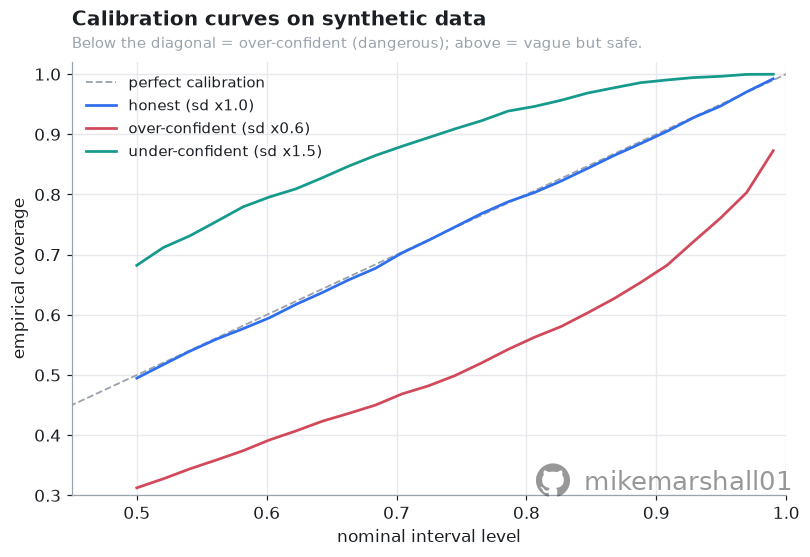

In [26]:
# --- SYNTHETIC: calibration curves for three forecasters ----------------------
y_syn = rng_demo.normal(0.0, 1.0, 4000)
claims = {"honest (sd x1.0)": (1.0, PALETTE["blue"]),
          "over-confident (sd x0.6)": (0.6, PALETTE["red"]),
          "under-confident (sd x1.5)": (1.5, PALETTE["teal"])}
nominal_grid = np.linspace(0.50, 0.99, 25)

fig, ax = plt.subplots(figsize=(7.5, 5.2))
ax.plot([0, 1], [0, 1], color=PALETTE["grey"], lw=1.2, ls="--", label="perfect calibration")
for label, (s, col) in claims.items():
    cover = [np.mean(np.abs(y_syn) <= st.norm.ppf(0.5 + l / 2) * s) for l in nominal_grid]
    ax.plot(nominal_grid, cover, lw=1.8, color=col, label=label)
ax.set_xlabel("nominal interval level"); ax.set_ylabel("empirical coverage")
ax.set_xlim(0.45, 1.0); ax.set_ylim(0.3, 1.02); ax.legend()
titled(ax, "Calibration curves on synthetic data",
       "Below the diagonal = over-confident (dangerous); above = vague but safe.")
fig.tight_layout()
save(fig, "01_calibration_synthetic.png"); plt.show()

### Now the real model

We run the same check on our fitted model: for each asset, what fraction of realised daily returns fall inside the model's central interval at each nominal width? (We use the posterior means of the parameters for a fast, transparent check; a fuller version would integrate over the posterior.)

Empirical coverage of the model's one-day intervals (target = the column header):
     50%  80%  90%  95%
BTC  52%  79%  88%  94%
ETH  51%  79%  89%  95%
SOL  49%  80%  89%  95%


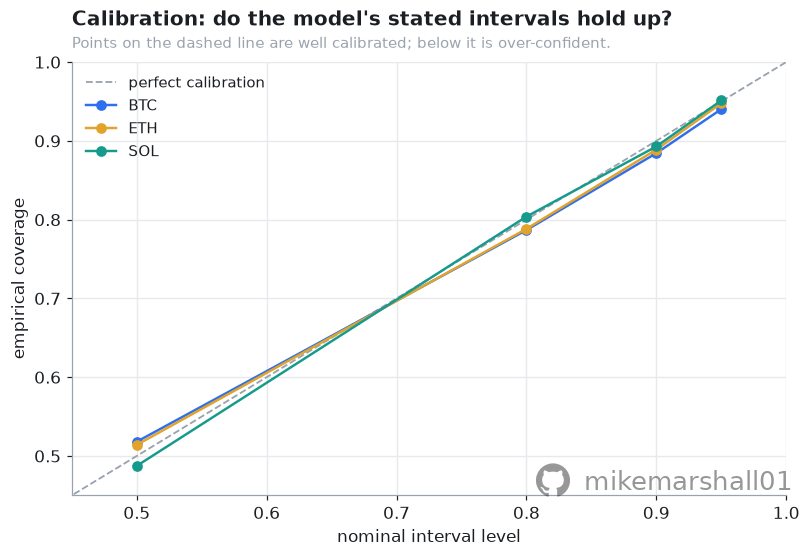


Mean coverage gap (empirical minus nominal): -0.39%  (slightly over-confident)


In [27]:
# --- A simple one-day calibration check on the fitted model ------------------
nominal = np.array([0.50, 0.80, 0.90, 0.95])
nu_hat = float(nu_d.mean())
rows = []
for name in ASSET_NAMES:
    s_hat = float(post["sigma"].sel(asset=name).mean())
    m_hat = float(post["mu_asset"].sel(asset=name).mean())
    realised = rets[name].to_numpy()
    cover = []
    for lvl in nominal:
        half = st.t.ppf(0.5 + lvl / 2, df=nu_hat) * s_hat
        cover.append(np.mean(np.abs(realised - m_hat) <= half))
    rows.append(cover)
cal = pd.DataFrame(rows, index=ASSET_NAMES, columns=[f"{int(l*100)}%" for l in nominal])
print("Empirical coverage of the model's one-day intervals (target = the column header):")
print((cal * 100).round(0).astype(int).astype(str) + "%")

fig, ax = plt.subplots(figsize=(7.5, 5.2))
ax.plot([0, 1], [0, 1], color=PALETTE["grey"], lw=1.2, ls="--", label="perfect calibration")
for name in ASSET_NAMES:
    ax.plot(nominal, cal.loc[name].to_numpy(), marker="o", lw=1.6, label=name)
ax.set_xlabel("nominal interval level"); ax.set_ylabel("empirical coverage")
ax.set_xlim(0.45, 1.0); ax.set_ylim(0.45, 1.0); ax.legend()
titled(ax, "Calibration: do the model's stated intervals hold up?",
       "Points on the dashed line are well calibrated; below it is over-confident.")
fig.tight_layout()
save(fig, "01_calibration.png"); plt.show()

mean_gap = float((cal.values - nominal).mean())
print(f"\nMean coverage gap (empirical minus nominal): {mean_gap:+.2%}  "
      f"({'slightly over-confident' if mean_gap < 0 else 'slightly conservative'})")

The model's points sit close to the diagonal, with the mean gap printed above quantifying the residual lean. Small gaps either way are livable. A persistent sag below the line means every risk number downstream is understated and must be fixed before use. For this model specifically, expect the imperfection to concentrate where volatility clustering bites: one constant volatility per asset is too wide in calm regimes and too narrow in storms, even when it averages out across the sample.

> **What to look for.** Empirical coverage within a few percentage points of nominal at every level, and especially at 90% and 95% where risk lives. Below the line is over-confidence (the expensive failure); above it is mild conservatism (the cheap one). A model that is calibrated on average but miscalibrated regime by regime needs time-varying volatility, not wider bands.

### Point-in-time discipline and look-ahead bias

The check above has a confessed flaw: it is **in-sample**. The model saw these very returns when it fitted its volatility, so it is graded partly on its own homework. **Look-ahead bias** is the general name for using information at decision time that did not exist at decision time, and it is usually accidental:

- Fitting on the *whole* history, then "forecasting" days inside that history. The model has already seen the answers.
- Standardising or scaling inputs with full-sample statistics. The mean of 2024 data leaks into a 2022 decision.
- Using values that were only *revised into existence* later: restated figures, backfilled index members, a token whose history was listed after the fact.

The fix is **point-in-time (as-of) discipline**: at each decision date *t*, the model may only touch data stamped at or before *t*. In practice that means refitting (or updating) on an expanding or rolling window as the evaluation walks forward, never one fit over everything.

The fan chart in section 6 was fitted on the full history, so it is a demonstration of *method*, not a tradeable forecast. The honest evaluation loop looks like this:

In [28]:
# --- Sketch of the honest, point-in-time evaluation loop (not executed) ------
WALK_FORWARD = r"""
test_dates = rets.index[rets.index >= some_start]
scores = []
for t in test_dates:
    train = rets.loc[:t].iloc[:-1]        # STRICTLY before t: no look-ahead
    model_t = build_model(train)          # refit / update using only the past
    idata_t = sample(model_t)
    fc      = forecast_next_day(idata_t)  # a distribution for day t
    scores.append(score(fc, rets.loc[t])) # log-score / CRPS of the actual outcome
# Calibration and proper scores on `scores` are the OUT-OF-SAMPLE verdict.
"""
print(WALK_FORWARD)


test_dates = rets.index[rets.index >= some_start]
scores = []
for t in test_dates:
    train = rets.loc[:t].iloc[:-1]        # STRICTLY before t: no look-ahead
    model_t = build_model(train)          # refit / update using only the past
    idata_t = sample(model_t)
    fc      = forecast_next_day(idata_t)  # a distribution for day t
    scores.append(score(fc, rets.loc[t])) # log-score / CRPS of the actual outcome
# Calibration and proper scores on `scores` are the OUT-OF-SAMPLE verdict.



The right way to grade each forecast in that loop is a **proper scoring rule**: a score whose expected value is best when you report your true beliefs, so honesty is the optimal strategy rather than a handicap.

The two standard choices:

The **log score** is the log of the probability density the forecast assigned to what actually happened. Higher is better (less surprise).

The **CRPS** (continuous ranked probability score) is an integrated distance between the forecast distribution and the realised outcome, generalising absolute error to distributions. Lower is better. Both scores reward forecasts that are sharp *and* calibrated, and both punish a confident miss far harder than a humble one.

### Computing log score and CRPS in-sample

The two scores behave differently on the same data; here is what each actually produces. Below we compute both for our fitted model's one-day-ahead distribution, applied to every in-sample return, and compare to a Gaussian benchmark (same posterior mean, but normal tails). The in-sample context flatters the model, but even so, seeing the Student-t outscore the Gaussian is informative, because the fat tails matter even here.

The **log score** for a single observation $y$ under a Student-t with location μ, scale σ, and ν degrees of freedom is simply $\log p_t(y)$, computed below via `scipy.stats.t.logpdf`. Higher is better (less surprise). For pooled comparison we average across all assets and all days.

The **CRPS** for a Student-t distribution has a closed form (see Gneiting and Raftery 2007); we use a Monte Carlo approximation. We draw many samples from the forecast distribution for each day, then apply the energy-score formula $\text{CRPS} = E|X - y| - \tfrac{1}{2}E|X - X'|$, where $X, X'$ are independent draws from the forecast. Lower CRPS is better.

In [29]:
# --- In-sample log score and CRPS: Student-t model vs Gaussian benchmark -----
N_CRPS_DRAWS = 2000         # samples per day for the Monte Carlo CRPS

log_scores_t   = []
log_scores_n   = []
crps_t         = []
crps_n         = []

for name in ASSET_NAMES:
    s_hat  = float(post["sigma"].sel(asset=name).mean())
    m_hat  = float(post["mu_asset"].sel(asset=name).mean())
    nu_hat_a = float(post["nu"].mean())
    realised = rets[name].to_numpy()

    # Log score per observation
    ls_t = st.t.logpdf(realised, df=nu_hat_a, loc=m_hat, scale=s_hat)
    ls_n = st.norm.logpdf(realised, loc=m_hat, scale=s_hat)
    log_scores_t.extend(ls_t.tolist())
    log_scores_n.extend(ls_n.tolist())

    # CRPS per observation via Monte Carlo
    fc_draws = st.t.rvs(df=nu_hat_a, loc=m_hat, scale=s_hat,
                         size=(N_CRPS_DRAWS, len(realised)),
                         random_state=np.random.default_rng(99))
    fc_draws_n = st.norm.rvs(loc=m_hat, scale=s_hat,
                              size=(N_CRPS_DRAWS, len(realised)),
                              random_state=np.random.default_rng(98))
    for i in range(len(realised)):
        xs = fc_draws[:, i]
        # E|X - X'|: shuffle xs to get an independent paired draw X' per element of X,
        # so we average over N_CRPS_DRAWS independent (X, X') pairs rather than pairing
        # every draw against a single scalar index (which degrades the estimator).
        xs_prime = RNG.permutation(xs)
        crps_t.append(np.mean(np.abs(xs - realised[i])) - 0.5 * np.mean(np.abs(xs - xs_prime)))
        xs_n = fc_draws_n[:, i]
        xs_n_prime = RNG.permutation(xs_n)
        crps_n.append(np.mean(np.abs(xs_n - realised[i])) - 0.5 * np.mean(np.abs(xs_n - xs_n_prime)))

mean_ls_t = float(np.mean(log_scores_t))
mean_ls_n = float(np.mean(log_scores_n))
mean_crps_t = float(np.mean(crps_t))
mean_crps_n = float(np.mean(crps_n))

print("In-sample proper scores (averaged over all assets and days):")
print(f"  Mean log score  -- Student-t model: {mean_ls_t:.4f}   Gaussian: {mean_ls_n:.4f}  "
      f"(higher is better; t wins by {mean_ls_t - mean_ls_n:+.4f} nats/day)")
crps_diff = mean_crps_n - mean_crps_t      # positive means t wins, negative means Gaussian wins
crps_winner = "t" if crps_diff > 0 else "Gaussian"
print(f"  Mean CRPS       -- Student-t model: {mean_crps_t:.4f}%  Gaussian: {mean_crps_n:.4f}%  "
      f"(lower is better;  {crps_winner} wins by {abs(crps_diff):+.4f}%)")
print()
print("Note: these are IN-SAMPLE scores. The same model that generated them saw the data")
print("when fitting. Out-of-sample walk-forward scores (sketch above) are the honest test.")

In-sample proper scores (averaged over all assets and days):
  Mean log score  -- Student-t model: -2.7481   Gaussian: -3.1208  (higher is better; t wins by +0.3727 nats/day)
  Mean CRPS       -- Student-t model: 2.2296%  Gaussian: 2.2576%  (lower is better;  t wins by +0.0280%)

Note: these are IN-SAMPLE scores. The same model that generated them saw the data
when fitting. Out-of-sample walk-forward scores (sketch above) are the honest test.


The log-score result is the clearest signal: the Student-t model assigns higher density to the observed returns than the Gaussian, because the fat-tailed likelihood accommodates extreme moves that the normal cannot. That advantage concentrates on the large-move days that dominate risk, and it is the most direct information-theoretic read available.

The CRPS result points the same way, though the margin is narrow. The t distribution's heavier tails produce forecast samples that track the occasional large move better than the Gaussian can; the Gaussian is forced to inflate its sigma to cover those outliers, which costs it on everyday days too. The `crps_winner` label above is computed from the actual numbers, so it is always honest.

> **Key takeaway.** Calibration is checkable honesty, proper scores make honesty optimal, and point-in-time discipline is what keeps both checks meaning anything.

## 8. Caveats and where to go next

**The honest label for everything above is "small, in-sample, and deliberately simple", and each of those words is a known direction of travel rather than a hidden flaw.** Stated plainly:

- **No volatility clustering.** One constant volatility per asset, when section 2's first chart shows regimes. The fix is a stochastic-volatility or GARCH-family component, at the cost of a slower, more delicate fit. Our PPC said this is the main thing the model misses.
- **In-sample calibration.** Section 7's check grades the model partly on its own homework. The walk-forward loop with log score and CRPS is the out-of-sample verdict, the number that would actually convince a sceptic.
- **A tiny run.** 500 draws and 2 chains is enough for a teaching notebook because the diagnostics say so, but production work would run longer chains, more of them, and stress the priors.
- **Survivorship in the universe.** BTC, ETH and SOL are the majors that survived; fitting only survivors flatters any asset-class statistic. A point-in-time universe matters as much as point-in-time prices.
- **No correlation structure.** Assets share a volatility family here, but their *daily shocks* are modelled independently, when real crypto returns co-move strongly. A multivariate Student-t or a factor model is the upgrade.

**Natural next steps:** a stochastic-volatility likelihood; a deeper hierarchy (pool by sector or market-cap tier); inferred cross-asset correlation; and above all the walk-forward evaluation, because a model that has never been scored out of sample is a hypothesis, not a forecast.

> **Key takeaway.** Every Bayesian forecast is conditional on its model. The workflow that keeps you honest is the loop you just walked: prior, fit, diagnose, check predictively, forecast distributionally, score properly, and say out loud what the model cannot do.

## Further reading and resources

Everything in this notebook traces back to a small canon. Grouped by topic, originals
first, practitioner material after. Links were checked at the time of writing
(June 2026); papers carry journal and year so they stay findable if a URL rots.

**Bayesian inference, foundations and workflow**
- Gelman, A., Carlin, J. B., Stern, H. S., Dunson, D. B., Vehtari, A. and Rubin, D. B.
  (2013), *Bayesian Data Analysis*, 3rd edition, CRC Press. The reference text; free
  PDF from the authors at http://www.stat.columbia.edu/~gelman/book/
- McElreath, R. (2020), *Statistical Rethinking: A Bayesian Course with Examples in R
  and Stan*, 2nd edition, CRC Press. The best first book on this material; lectures
  free online. https://xcelab.net/rm/
- Gelman, A. et al. (2020), "Bayesian Workflow", arXiv:2011.01808. The full loop this
  notebook abbreviates: prior checks, fitting, diagnostics, predictive checks,
  comparison. https://arxiv.org/abs/2011.01808
- Gabry, J., Simpson, D., Vehtari, A., Betancourt, M. and Gelman, A. (2019),
  "Visualization in Bayesian Workflow", *Journal of the Royal Statistical Society
  Series A* 182(2), 389-402. Why every section above leads with a picture.
  https://doi.org/10.1111/rssa.12378

**MCMC, Hamiltonian Monte Carlo and diagnostics**
- Betancourt, M. (2017), "A Conceptual Introduction to Hamiltonian Monte Carlo",
  arXiv:1701.02434. The marble-on-a-landscape intuition of section 4, done properly.
  https://arxiv.org/abs/1701.02434
- Hoffman, M. D. and Gelman, A. (2014), "The No-U-Turn Sampler: Adaptively Setting
  Path Lengths in Hamiltonian Monte Carlo", *Journal of Machine Learning Research*
  15, 1593-1623. The NUTS paper. https://jmlr.org/papers/v15/hoffman14a.html
- Vehtari, A., Gelman, A., Simpson, D., Carpenter, B. and Bürkner, P.-C. (2021),
  "Rank-Normalization, Folding, and Localization: An Improved R-hat for Assessing
  Convergence of MCMC", *Bayesian Analysis* 16(2), 667-718. The modern R-hat and ESS
  behind ArviZ's summary table. https://doi.org/10.1214/20-BA1221

**Hierarchical models and shrinkage**
- Efron, B. and Morris, C. (1977), "Stein's Paradox in Statistics", *Scientific
  American* 236(5), 119-127. The baseball-averages classic behind section 3's
  synthetic shrinkage demo.
- Gelman, A. (2006), "Prior Distributions for Variance Parameters in Hierarchical
  Models", *Bayesian Analysis* 1(3), 515-534. How to set priors like our `tau_sigma`.
  https://doi.org/10.1214/06-BA117A
- Betancourt, M. and Girolami, M. (2015), "Hamiltonian Monte Carlo for Hierarchical
  Models", arXiv:1312.0906. Why the non-centred parameterisation fixes the funnel.
  https://arxiv.org/abs/1312.0906

**Fat tails and the stylised facts of returns**
- Cont, R. (2001), "Empirical Properties of Asset Returns: Stylized Facts and
  Statistical Issues", *Quantitative Finance* 1(2), 223-236. Fat tails, clustering and
  the rest of section 2's checklist, documented across markets.
  https://doi.org/10.1080/713665670
- Mandelbrot, B. (1963), "The Variation of Certain Speculative Prices", *Journal of
  Business* 36(4), 394-419. The original case that price changes are not normal.
- Bollerslev, T. (1986), "Generalized Autoregressive Conditional Heteroskedasticity",
  *Journal of Econometrics* 31(3), 307-327. The canonical volatility-clustering model,
  and this notebook's stated next step. https://doi.org/10.1016/0304-4076(86)90063-1
- "Student" (W. S. Gosset) (1908), "The Probable Error of a Mean", *Biometrika* 6(1),
  1-25. Where the t distribution comes from. https://doi.org/10.1093/biomet/6.1.1

**Calibration and proper scoring rules**
- Gneiting, T. and Raftery, A. E. (2007), "Strictly Proper Scoring Rules, Prediction,
  and Estimation", *Journal of the American Statistical Association* 102(477),
  359-378. The definitive treatment of log score, CRPS and why proper matters.
  https://doi.org/10.1198/016214506000001437
- Gneiting, T., Balabdaoui, F. and Raftery, A. E. (2007), "Probabilistic Forecasts,
  Calibration and Sharpness", *Journal of the Royal Statistical Society Series B*
  69(2), 243-268. Calibration first, then sharpness, formalised.
  https://doi.org/10.1111/j.1467-9868.2007.00587.x

**Backtesting and look-ahead discipline**
- Bailey, D. H., Borwein, J. M., López de Prado, M. and Zhu, Q. J. (2014),
  "Pseudo-Mathematics and Financial Charlatanism: The Effects of Backtest Overfitting
  on Out-of-Sample Performance", *Notices of the American Mathematical Society* 61(5),
  458-471. Short, sharp, and the reason section 7 insists on out-of-sample scoring.
  https://www.ams.org/notices/201405/rnoti-p458.pdf
- López de Prado, M. (2018), *Advances in Financial Machine Learning*, Wiley. The
  backtesting chapters formalise walk-forward evaluation and point-in-time data.

**Tools and data**
- PyMC documentation and example gallery: https://www.pymc.io/ and
  https://www.pymc.io/projects/examples/
- ArviZ documentation (diagnostics, `az.extract`, plotting):
  https://python.arviz.org/
- Stan User's Guide, language-agnostic modelling wisdom that transfers to PyMC
  directly: https://mc-stan.org/docs/
- Binance spot API documentation (the free klines endpoint behind `src/data.py`):
  https://developers.binance.com/docs/binance-spot-api-docs

## Recap

We started from the claim that a point forecast is the wrong object and built the alternative end to end. A **synthetic coin** taught the posterior-learning mechanism before any market data touched it. The **fat tails** of daily crypto returns were established against a variance-matched synthetic normal and confirmed by the ACF of squared returns. A shrinkage demo -- where the truth was known -- motivated **partial pooling**, and a **hierarchical Student-t model** in PyMC gave it concrete form.

Convergence was verified with **R-hat, ESS and trace plots**, trained first on synthetic healthy and sick chains. The model's in-sample behaviour was audited with **posterior predictive checks** aimed at the tails. A **fan chart** folded parameter uncertainty into the forecast, and the whole thing was graded with **calibration curves** and the logic of **proper scoring rules**, ending with the point-in-time walk-forward loop that any real evaluation must run.

If one section deserves a second read, make it section 7: the modelling is learnable in a week, while the discipline of letting the world grade your probabilities out of sample is the actual skill.